<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/15min/06B_LSTM_Recovery_Global_Final_and_Comparison_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06B — LSTM Recovery: Final Global Model + Final Comparisons

This recovery notebook exists only because the original LSTM Colab runtime disconnected during the **final global LSTM training**.

It deliberately does **not** repeat:

- LSTM lookback tuning;
- learning-rate tuning;
- inner global epoch selection;
- the four asset-specific LSTM fits.

Those steps completed successfully in the interrupted run.

## Frozen results recovered from the completed run

The executed Notebook 06 selected:

- **LSTM lookback:** `12h`
- **LSTM lookback bars at 15m:** `48`
- **Learning rate:** `3e-4`
- **Global final epoch count:** `21`

The four asset-specific LSTMs also completed and were saved before the disconnect.

Their Validation QLIKE values were:

- BTC: `1.436966`
- ETH: `1.504460`
- SOL: `1.440162`
- XRP: `1.576040`

## What this notebook does

1. verifies that the saved asset-specific LSTM models, scalers and Validation predictions exist;
2. reconstructs the exact full-Train feature / sequence setup used by Notebook 06;
3. trains **only the final Global LSTM** for the already-selected 21 epochs;
4. saves the final Global LSTM and its scalers;
5. reconstructs aggregate asset-specific LSTM outputs from the already-saved per-asset prediction files;
6. compares final LSTM / GRU / MLP / ARCH models on identical Validation timestamps;
7. creates the final QLIKE and volatility-comparison figures;
8. saves the final LSTM output tables / configuration;
9. keeps Test untouched.

No hyperparameter is selected in this notebook.

## 1. Imports and Drive

In [1]:
from google.colab import drive
from pathlib import Path
from datetime import datetime, timezone
import gc, json, math, os, random, time, warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, LayerNormalization, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.initializers import Constant

drive.mount("/content/drive")

BASE_SEED = 52
os.environ["PYTHONHASHSEED"] = str(BASE_SEED)
random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
tf.keras.utils.set_random_seed(BASE_SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic operations enabled.")
except Exception as e:
    print("Deterministic-op request unavailable:", e)

print("TensorFlow:", tf.__version__)

Mounted at /content/drive
TensorFlow deterministic operations enabled.
TensorFlow: 2.20.0


## 2. Recovery configuration

In [2]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Quant Research/15min"
)

KLINE_INTERVAL = "15m"

SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "SOLUSDT",
    "XRPUSDT",
]

EPSILON = 1e-12

# ============================================================
# FROZEN FROM THE COMPLETED NOTEBOOK 06 TUNING OUTPUTS
# ============================================================

SELECTED_LSTM_DURATION = "12h"
SELECTED_LSTM_BARS = 48
SELECTED_LSTM_LR = 3e-4
GLOBAL_FINAL_EPOCHS = 21

# Asset-specific selected epochs are included for provenance only.
# They are NOT retrained in this recovery notebook.
SELECTED_EPOCH_BY_ASSET = {
    "BTCUSDT": 20,
    "ETHUSDT": 10,
    "SOLUSDT": 19,
    "XRPUSDT": 7,
}

# ============================================================
# Same feature / architecture configuration as Notebook 06
# ============================================================

RV_STATE_DURATIONS = [
    "30min",
    "1h",
    "2h",
    "4h",
    "8h",
    "12h",
    "1d",
]

RANGE_DURATIONS = [
    "1h",
    "4h",
    "1d",
]

SEMIVAR_DURATIONS = [
    "1h",
    "4h",
    "1d",
]

ACTIVITY_DURATIONS = [
    "4h",
    "1d",
]

LAG_DURATIONS = [
    "30min",
    "1h",
    "2h",
    "4h",
]

BATCH_SIZE = 1024
WEIGHT_DECAY = 1e-5
CLIPNORM = 1.0

LSTM_UNITS = 64
SEQUENCE_DROPOUT = 0.08
STATE_DROPOUT = 0.08
HEAD_DROPOUT = 0.05

ROLLING_VOLATILITY_WINDOW = "1d"
PLOT_WINDOW_DURATION = "14d"
PLOT_START = None

MANIFEST_ROOT = (
    PROJECT_ROOT
    / "manifests"
    / KLINE_INTERVAL
)

MODEL_READY_ROOT = (
    PROJECT_ROOT
    / "data"
    / "model_ready"
    / KLINE_INTERVAL
)

MODEL_ROOT = (
    PROJECT_ROOT
    / "models"
    / KLINE_INTERVAL
    / "LSTM_FINAL"
)

ARTIFACT_ROOT = (
    PROJECT_ROOT
    / "artifacts"
    / KLINE_INTERVAL
    / "LSTM_FINAL"
)

RESULTS_ROOT = (
    PROJECT_ROOT
    / "results"
    / KLINE_INTERVAL
    / "LSTM_FINAL"
)

for directory in [
    MODEL_READY_ROOT,
    MODEL_ROOT,
    ARTIFACT_ROOT,
    RESULTS_ROOT,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

BASE_SEED = 52

os.environ[
    "PYTHONHASHSEED"
] = str(
    BASE_SEED
)

random.seed(
    BASE_SEED
)

np.random.seed(
    BASE_SEED
)

tf.keras.utils.set_random_seed(
    BASE_SEED
)

# Exact reproducibility setting from completed Notebook 06.
# BASE_SEED has already been explicitly set and all RNGs reset above.

# Frozen from completed Notebook 06 tuning.
assert SELECTED_LSTM_DURATION == "12h"
assert SELECTED_LSTM_BARS == 48
assert np.isclose(SELECTED_LSTM_LR, 3e-4)
assert GLOBAL_FINAL_EPOCHS == 21

print(
    "Recovery configuration:"
)

print(
    "Lookback:",
    SELECTED_LSTM_DURATION,
    "=",
    SELECTED_LSTM_BARS,
    "bars",
)

print(
    "Learning rate:",
    SELECTED_LSTM_LR,
)

print(
    "Global final epochs:",
    GLOBAL_FINAL_EPOCHS,
)

Recovery configuration:
Lookback: 12h = 48 bars
Learning rate: 0.0003
Global final epochs: 21


## 3. Verify the expensive completed asset-specific work is already on Drive

This cell fails immediately if any of the four asset-specific models / scalers / prediction files were not saved before the runtime disconnect.

In [3]:
ASSET_MODEL_PATHS = {}
ASSET_SCALER_PATHS = {}
ASSET_PREDICTION_PATHS = {}

for symbol in SYMBOLS:

    model_path = (
        MODEL_ROOT
        / symbol
        / "final_asset_specific_lstm.keras"
    )

    scaler_path = (
        ARTIFACT_ROOT
        / symbol
        / "lstm_scalers.joblib"
    )

    prediction_path = (
        RESULTS_ROOT
        / symbol
        / "validation_predictions.parquet"
    )

    history_path = (
        RESULTS_ROOT
        / symbol
        / "final_train_history.csv"
    )

    for required_path in [
        model_path,
        scaler_path,
        prediction_path,
        history_path,
    ]:
        if not required_path.exists():
            raise FileNotFoundError(
                "A completed asset-specific LSTM artifact "
                "is missing. Do not start Global training.\n"
                f"Missing: {required_path}"
            )

    ASSET_MODEL_PATHS[
        symbol
    ] = model_path

    ASSET_SCALER_PATHS[
        symbol
    ] = scaler_path

    ASSET_PREDICTION_PATHS[
        symbol
    ] = prediction_path


asset_prediction_parts = []

for symbol in SYMBOLS:

    prediction_df = pd.read_parquet(
        ASSET_PREDICTION_PATHS[
            symbol
        ]
    )

    prediction_df[
        "target_open_time"
    ] = pd.to_datetime(
        prediction_df[
            "target_open_time"
        ],
        utc=True,
        errors="raise",
    )

    if (
        prediction_df[
            "symbol"
        ]
        .nunique()
        != 1
        or prediction_df[
            "symbol"
        ]
        .iloc[0]
        != symbol
    ):
        raise ValueError(
            f"{symbol}: saved prediction artifact has "
            "an unexpected symbol."
        )

    if len(
        prediction_df
    ) != 35040:
        raise ValueError(
            f"{symbol}: expected 35,040 saved Validation "
            f"predictions, found {len(prediction_df)}."
        )

    asset_prediction_parts.append(
        prediction_df
    )


asset_lstm_predictions_df = (
    pd.concat(
        asset_prediction_parts,
        ignore_index=True,
    )
)

print(
    "ALL FOUR ASSET-SPECIFIC LSTM ARTIFACT SETS FOUND."
)

print(
    "Saved asset-specific Validation predictions:",
    len(
        asset_lstm_predictions_df
    ),
)

ALL FOUR ASSET-SPECIFIC LSTM ARTIFACT SETS FOUND.
Saved asset-specific Validation predictions: 140160


## 4. Load canonical Notebook 02 data and enforce one-candle target alignment

In [4]:
manifest_candidates = sorted(
    MANIFEST_ROOT.glob(
        f"processing_manifest_{KLINE_INTERVAL}_v*.json"
    )
)

if len(manifest_candidates) != 1:
    raise FileNotFoundError(
        "Expected exactly one processing manifest for "
        f"{KLINE_INTERVAL}; found {len(manifest_candidates)}."
    )

PROCESSING_MANIFEST_PATH = manifest_candidates[0]

processing_manifest = json.loads(
    PROCESSING_MANIFEST_PATH.read_text(
        encoding="utf-8"
    )
)

if (
    processing_manifest["kline_interval"]
    != KLINE_INTERVAL
):
    raise ValueError(
        "Processing-manifest interval mismatch."
    )

INTERVAL_MINUTES = int(
    processing_manifest["interval_minutes"]
)

INTERVAL_MS = int(
    processing_manifest["interval_ms"]
)

INTERVAL_DELTA = pd.Timedelta(
    minutes=INTERVAL_MINUTES
)

split_cfg = (
    processing_manifest[
        "split_boundaries_utc"
    ]
)

VALIDATION_START = pd.Timestamp(
    split_cfg[
        "validation_target_start"
    ]
)

TEST_START = pd.Timestamp(
    split_cfg[
        "validation_target_end_exclusive"
    ]
)

TEST_END_EXCLUSIVE = pd.Timestamp(
    split_cfg[
        "test_target_end_exclusive"
    ]
)

FEATURES_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "full_features_parquet"
    ]
)

MODEL_ROWS_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "valid_model_rows_parquet"
    ]
)

SEASONALITY_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "seasonality_factors_parquet"
    ]
)

RAW_PATH = Path(
    processing_manifest[
        "source_raw_parquet"
    ]
)

for required_path in [
    FEATURES_PATH,
    MODEL_ROWS_PATH,
    SEASONALITY_PATH,
    RAW_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            required_path
        )


features_df = pd.read_parquet(
    FEATURES_PATH
)

canonical_model_rows_df = pd.read_parquet(
    MODEL_ROWS_PATH
)

full_train_seasonality_df = pd.read_parquet(
    SEASONALITY_PATH
)

raw_df = pd.read_parquet(
    RAW_PATH
)


for frame in [
    features_df,
    canonical_model_rows_df,
]:
    frame[
        "open_time"
    ] = pd.to_datetime(
        frame[
            "open_time"
        ],
        utc=True,
        errors="raise",
    )

    frame[
        "target_open_time"
    ] = pd.to_datetime(
        frame[
            "target_open_time"
        ],
        utc=True,
        errors="coerce",
    )

raw_df[
    "open_time"
] = pd.to_datetime(
    raw_df[
        "open_time"
    ],
    utc=True,
    errors="raise",
)


print(
    "Interval:",
    INTERVAL_DELTA,
)

print(
    "Validation:",
    VALIDATION_START,
    "to",
    TEST_START,
)


# ============================================================
# Upstream schema QC
# ============================================================

_required_full_columns = {
    "symbol",
    "open_time",
    "target_open_time",
    "split",
    "return",
    "realized_variance",
    "target_return",
    "target_realized_variance",
    "standard_duration_candle",
}

_required_model_columns = {
    "symbol",
    "open_time",
    "target_open_time",
    "split",
    "target_return",
    "target_realized_variance",
}

_missing_full = (
    _required_full_columns
    - set(
        features_df.columns
    )
)

_missing_model = (
    _required_model_columns
    - set(
        canonical_model_rows_df.columns
    )
)

if _missing_full:
    raise ValueError(
        "Full-feature parquet is missing: "
        f"{_missing_full}"
    )

if _missing_model:
    raise ValueError(
        "Canonical model-row parquet is missing: "
        f"{_missing_model}"
    )


assert not features_df.duplicated(
    [
        "symbol",
        "open_time",
    ]
).any()

assert not canonical_model_rows_df.duplicated(
    [
        "symbol",
        "open_time",
    ]
).any()


# ============================================================
# IMPORTANT:
# full_features_parquet intentionally retains historical rows
# around exchange gaps. For such rows, target_open_time can be
# the next OBSERVED candle and therefore be > one interval away.
#
# The strict one-candle-ahead assertion belongs on Notebook 02's
# VALID MODEL ROWS, not on every row of the full historical table.
# ============================================================

_canonical_alignment = (
    canonical_model_rows_df[
        "target_open_time"
    ]
    - canonical_model_rows_df[
        "open_time"
    ]
)

if not _canonical_alignment.eq(
    INTERVAL_DELTA
).all():
    bad = (
        canonical_model_rows_df.loc[
            ~_canonical_alignment.eq(
                INTERVAL_DELTA
            ),
            [
                "symbol",
                "open_time",
                "target_open_time",
            ],
        ]
        .head(10)
    )

    raise ValueError(
        "Canonical Notebook 02 model rows contain "
        "non-one-candle targets.\n"
        f"{bad}"
    )


# Target identity on the canonical prediction rows.
_target_identity_ok = np.allclose(
    canonical_model_rows_df[
        "target_realized_variance"
    ].to_numpy(
        dtype=float
    ),
    (
        canonical_model_rows_df[
            "target_return"
        ].to_numpy(
            dtype=float
        )
        ** 2
    ),
    rtol=1e-10,
    atol=1e-18,
    equal_nan=False,
)

if not _target_identity_ok:
    raise ValueError(
        "Canonical target variance is not equal "
        "to squared next-candle return."
    )


# Split boundaries are checked only on canonical valid targets.
_train_mask = (
    canonical_model_rows_df[
        "split"
    ].eq(
        "train"
    )
)

_validation_mask = (
    canonical_model_rows_df[
        "split"
    ].eq(
        "validation"
    )
)

_test_mask = (
    canonical_model_rows_df[
        "split"
    ].eq(
        "test"
    )
)

assert canonical_model_rows_df.loc[
    _train_mask,
    "target_open_time",
].lt(
    VALIDATION_START
).all()

assert canonical_model_rows_df.loc[
    _validation_mask,
    "target_open_time",
].ge(
    VALIDATION_START
).all()

assert canonical_model_rows_df.loc[
    _validation_mask,
    "target_open_time",
].lt(
    TEST_START
).all()

assert canonical_model_rows_df.loc[
    _test_mask,
    "target_open_time",
].ge(
    TEST_START
).all()

assert canonical_model_rows_df.loc[
    _test_mask,
    "target_open_time",
].lt(
    TEST_END_EXCLUSIVE
).all()


# ============================================================
# Mark the full historical rows that Notebook 02 accepts as
# legitimate fixed-horizon model targets.
#
# We still retain all full-feature rows as potential PAST context
# for LSTM sequences, but only canonical_model_row=True can be a
# forecast endpoint / supervised target.
# ============================================================

_canonical_keys = (
    canonical_model_rows_df[
        [
            "symbol",
            "open_time",
        ]
    ]
    .copy()
)

_canonical_keys[
    "canonical_model_row"
] = True

features_df = (
    features_df
    .merge(
        _canonical_keys,
        on=[
            "symbol",
            "open_time",
        ],
        how="left",
        validate="one_to_one",
    )
)

features_df[
    "canonical_model_row"
] = (
    features_df[
        "canonical_model_row"
    ]
    .fillna(
        False
    )
    .astype(bool)
)


if int(
    features_df[
        "canonical_model_row"
    ].sum()
) != len(
    canonical_model_rows_df
):
    raise ValueError(
        "Canonical model-row mapping back to the "
        "full feature table is incomplete."
    )


_full_alignment = (
    features_df[
        "target_open_time"
    ]
    - features_df[
        "open_time"
    ]
)

features_df[
    "target_interval_valid"
] = (
    features_df[
        "target_open_time"
    ]
    .notna()
    & _full_alignment.eq(
        INTERVAL_DELTA
    )
)


# Every canonical target must be exactly one configured candle ahead.
assert features_df.loc[
    features_df[
        "canonical_model_row"
    ],
    "target_interval_valid",
].all()


_noncanonical_nonunit = int(
    (
        features_df[
            "target_open_time"
        ]
        .notna()
        & ~features_df[
            "target_interval_valid"
        ]
    )
    .sum()
)

print(
    "Canonical fixed-horizon model rows:",
    len(
        canonical_model_rows_df
    ),
)

print(
    "Full-history rows with a non-unit next-observed gap:",
    _noncanonical_nonunit,
)

print(
    "Canonical target/split alignment QC passed."
)

# ============================================================
# Dynamic Validation-row expectation + saved asset prediction QC
# ============================================================

_validation_span = (
    TEST_START
    - VALIDATION_START
)

if (
    int(
        _validation_span.value
    )
    % int(
        INTERVAL_DELTA.value
    )
    != 0
):
    raise ValueError(
        "Validation window is not an exact multiple of "
        "the configured candle interval."
    )

EXPECTED_VALIDATION_ROWS = int(
    _validation_span
    / INTERVAL_DELTA
)

for _symbol in SYMBOLS:

    _asset_saved = (
        asset_lstm_predictions_df.loc[
            asset_lstm_predictions_df[
                "symbol"
            ].eq(
                _symbol
            )
        ]
        .sort_values(
            "target_open_time"
        )
        .copy()
    )

    if (
        len(
            _asset_saved
        )
        != EXPECTED_VALIDATION_ROWS
    ):
        raise ValueError(
            f"{_symbol}: saved asset LSTM Validation rows "
            f"{len(_asset_saved)} != expected "
            f"{EXPECTED_VALIDATION_ROWS}."
        )

    if _asset_saved.duplicated(
        [
            "symbol",
            "target_open_time",
        ]
    ).any():
        raise ValueError(
            f"{_symbol}: duplicate saved asset-LSTM "
            "Validation timestamps."
        )

    if (
        _asset_saved[
            "target_open_time"
        ].min()
        != VALIDATION_START
    ):
        raise ValueError(
            f"{_symbol}: saved asset-LSTM Validation "
            "does not begin at the canonical boundary."
        )

    if (
        _asset_saved[
            "target_open_time"
        ].max()
        != (
            TEST_START
            - INTERVAL_DELTA
        )
    ):
        raise ValueError(
            f"{_symbol}: saved asset-LSTM Validation "
            "does not end at the canonical boundary."
        )

    if not np.isfinite(
        _asset_saved[
            "predicted_variance"
        ].to_numpy(
            dtype=float
        )
    ).all():
        raise ValueError(
            f"{_symbol}: non-finite saved asset-LSTM forecasts."
        )

    if not (
        _asset_saved[
            "predicted_variance"
        ]
        .gt(
            0
        )
        .all()
    ):
        raise ValueError(
            f"{_symbol}: non-positive saved asset-LSTM forecasts."
        )

print(
    "Expected Validation rows per asset:",
    EXPECTED_VALIDATION_ROWS,
)

print(
    "Saved asset-specific LSTM Validation artifacts passed "
    "dynamic coverage QC."
)


Interval: 0 days 00:15:00
Validation: 2024-08-01 00:00:00+00:00 to 2025-08-01 00:00:00+00:00


/tmp/ipykernel_3115/2465772649.py:412: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(


Canonical fixed-horizon model rows: 1114295
Full-history rows with a non-unit next-observed gap: 102
Canonical target/split alignment QC passed.
Expected Validation rows per asset: 35040
Saved asset-specific LSTM Validation artifacts passed dynamic coverage QC.


## 5. Merge raw OHLC / activity variables

In [5]:
raw_extra = raw_df[[
    "symbol","open_time_ms","open","high","low",
    "quote_asset_volume","number_of_trades","taker_buy_quote_asset_volume"
]].copy()

base_df = (
    features_df
    .merge(raw_extra, on=["symbol","open_time_ms"], how="left", validate="one_to_one")
    .sort_values(["symbol","open_time"])
    .reset_index(drop=True)
)

required = [
    "open","high","low","quote_asset_volume",
    "number_of_trades","taker_buy_quote_asset_volume"
]
if base_df[required].isna().any().any():
    raise ValueError("Unexpected nulls after raw-data merge.")

assert not base_df.duplicated(["symbol","open_time_ms"]).any()
print("Merged rows:", len(base_df))

Merged rows: 1125147


## 6. Dynamic duration helpers

In [6]:
def duration_to_bars_or_none(duration):
    td = pd.Timedelta(duration)
    if td < INTERVAL_DELTA:
        return None
    if int(td.value) % int(INTERVAL_DELTA.value) != 0:
        return None
    bars = int(td.value // INTERVAL_DELTA.value)
    return bars if bars >= 1 else None

def duration_tag(duration):
    return str(duration).lower().replace(" ","").replace("minutes","min").replace("minute","min").replace("/","_")

def duration_map(items):
    out = {}
    for d in items:
        b = duration_to_bars_or_none(d)
        if b is not None:
            out[str(d)] = b
    return out

RV_STATE_BARS = duration_map(RV_STATE_DURATIONS)
RANGE_BARS = duration_map(RANGE_DURATIONS)
SEMIVAR_BARS = duration_map(SEMIVAR_DURATIONS)
ACTIVITY_BARS = duration_map(ACTIVITY_DURATIONS)


# Dynamic lag specification used by the original final LSTM.
# Always include one-candle lag, then add distinct elapsed-time lags.
LAG_BAR_SPECS = [
    ("1c", 1)
]

_seen_lag_bars = {
    1
}

for _duration in LAG_DURATIONS:

    _bars = duration_to_bars_or_none(
        _duration
    )

    if (
        _bars is not None
        and _bars not in _seen_lag_bars
    ):
        LAG_BAR_SPECS.append(
            (
                duration_tag(
                    _duration
                ),
                int(
                    _bars
                ),
            )
        )

        _seen_lag_bars.add(
            int(
                _bars
            )
        )


selected_bars_from_duration = duration_to_bars_or_none(
    SELECTED_LSTM_DURATION
)

if selected_bars_from_duration is None:
    raise ValueError(
        "Frozen LSTM duration is incompatible with the configured candle interval."
    )

if int(selected_bars_from_duration) != int(SELECTED_LSTM_BARS):
    raise ValueError(
        "Frozen duration/bar mismatch: "
        f"{SELECTED_LSTM_DURATION} resolves to {selected_bars_from_duration} bars, "
        f"but the completed tuning selected {SELECTED_LSTM_BARS}."
    )

print(
    "Frozen LSTM lookback verified:",
    SELECTED_LSTM_DURATION,
    "=",
    SELECTED_LSTM_BARS,
    "bars",
)

# ------------------------------------------------------------
# Dynamic lag / lookback integrity QC
# ------------------------------------------------------------

assert len(
    LAG_BAR_SPECS
) == len(
    {
        bars
        for _, bars in LAG_BAR_SPECS
    }
)

assert LAG_BAR_SPECS[
    0
] == (
    "1c",
    1,
)

for _tag, _bars in LAG_BAR_SPECS:
    assert isinstance(
        _bars,
        int,
    )

    assert (
        _bars
        >= 1
    )

print(
    "LSTM lag specification:",
    LAG_BAR_SPECS,
)


Frozen LSTM lookback verified: 12h = 48 bars
LSTM lag specification: [('1c', 1), ('30min', 2), ('1h', 4), ('2h', 8), ('4h', 16)]


## 7. Full-Train seasonality QC

In [7]:
def clock_slot_index(ts):
    return (ts.dt.hour * 60 + ts.dt.minute) // INTERVAL_MINUTES

def estimate_seasonality(source_df, fit_end_exclusive):
    x = source_df.loc[
        source_df["open_time"].lt(fit_end_exclusive)
        & source_df["realized_variance"].notna(),
        ["symbol","open_time","realized_variance"]
    ].copy()
    x["slot_index"] = clock_slot_index(x["open_time"]).astype(int)
    parts = []
    for symbol in SYMBOLS:
        s = x.loc[x["symbol"].eq(symbol)]
        overall = float(s["realized_variance"].mean())
        if not np.isfinite(overall) or overall <= 0:
            raise ValueError(f"{symbol}: invalid seasonality mean.")
        g = s.groupby("slot_index",as_index=False).agg(
            observations=("realized_variance","size"),
            mean_rv=("realized_variance","mean"),
        )
        g["symbol"] = symbol
        g["variance_seasonality_factor"] = g["mean_rv"] / overall
        parts.append(g)
    out = pd.concat(parts,ignore_index=True)
    expected_slots = int(pd.Timedelta(days=1) / INTERVAL_DELTA)
    assert out.groupby("symbol")["slot_index"].nunique().eq(expected_slots).all()
    assert out["variance_seasonality_factor"].gt(0).all()
    return out

def strict_rolling_mean(values,times,bars):
    mean = values.rolling(bars,min_periods=bars).mean()
    count = values.rolling(bars,min_periods=bars).count()
    start = times.shift(bars-1)
    exact = (times-start).eq((bars-1)*INTERVAL_DELTA)
    return mean.where(count.eq(bars) & exact)

def strict_lag(values,times,bars):
    sv = values.shift(bars)
    st = times.shift(bars)
    return sv.where((times-st).eq(bars*INTERVAL_DELTA))

expected_slots = int(pd.Timedelta(days=1) / INTERVAL_DELTA)
assert full_train_seasonality_df.groupby("symbol")["slot_index"].nunique().eq(expected_slots).all()

print("Full-Train seasonality QC passed.")

Full-Train seasonality QC passed.


## 8. Enhanced state / sequence feature definitions

In [8]:
BASE_STATE = [
    "log_adj_rv","deseason_return","abs_deseason_return",
    "intrabar_oc_return_deseason",
    "target_time_sin","target_time_cos","target_dow_sin","target_dow_cos"
]
RV_ROLL = [f"log_rv_mean_{duration_tag(d)}" for d in RV_STATE_BARS]
RV_LAG = [f"lag_log_adj_rv_{tag}" for tag,_ in LAG_BAR_SPECS]

RV_RATIO = []
if "1d" in RV_STATE_BARS:
    for d in RV_STATE_BARS:
        if d != "1d":
            RV_RATIO.append(f"log_rv_ratio_{duration_tag(d)}_to_1d")

RANGE_STATE = ["log_parkinson_adj","log_garman_klass_adj"]
for d in RANGE_BARS:
    tag = duration_tag(d)
    RANGE_STATE += [f"log_parkinson_mean_{tag}",f"log_garman_klass_mean_{tag}"]

SEMIVAR_STATE = []
for d in SEMIVAR_BARS:
    tag = duration_tag(d)
    SEMIVAR_STATE += [f"log_positive_semivar_mean_{tag}",f"log_negative_semivar_mean_{tag}"]

ACTIVITY_STATE = ["log_quote_volume","log_trade_count","taker_imbalance","log_average_trade_size"]
for d in ACTIVITY_BARS:
    tag = duration_tag(d)
    ACTIVITY_STATE += [f"quote_volume_surprise_{tag}",f"trade_count_surprise_{tag}"]

STATE_FEATURE_COLUMNS = BASE_STATE + RV_ROLL + RV_LAG + RV_RATIO + RANGE_STATE + SEMIVAR_STATE + ACTIVITY_STATE

SEQUENCE_FEATURE_COLUMNS = [
    "log_adj_rv","deseason_return","abs_deseason_return",
    "intrabar_oc_return_deseason","log_parkinson_adj",
    "log_garman_klass_adj","log_quote_volume","log_trade_count",
    "taker_imbalance","log_average_trade_size",
    "positive_semivar","negative_semivar"
]

assert len(STATE_FEATURE_COLUMNS) == len(set(STATE_FEATURE_COLUMNS))
assert len(SEQUENCE_FEATURE_COLUMNS) == len(set(SEQUENCE_FEATURE_COLUMNS))
print("State features:", len(STATE_FEATURE_COLUMNS))
print("Sequence features:", len(SEQUENCE_FEATURE_COLUMNS))
# ------------------------------------------------------------
# Explicit feature-leakage guard
# ------------------------------------------------------------
KNOWN_AHEAD_TARGET_FEATURES = {
    "target_time_sin", "target_time_cos",
    "target_dow_sin", "target_dow_cos",
}

for _column in STATE_FEATURE_COLUMNS + SEQUENCE_FEATURE_COLUMNS:
    if _column.startswith("target_") and _column not in KNOWN_AHEAD_TARGET_FEATURES:
        raise ValueError(f"Potential target leakage feature detected: {_column}")

for _forbidden in [
    "target_realized_variance",
    "target_adjusted_variance",
    "target_return",
]:
    assert _forbidden not in STATE_FEATURE_COLUMNS
    assert _forbidden not in SEQUENCE_FEATURE_COLUMNS

print("Explicit feature-leakage guard passed.")


# ------------------------------------------------------------
# Recovery feature-shape QC
# ------------------------------------------------------------

if len(
    STATE_FEATURE_COLUMNS
) != 48:
    raise ValueError(
        "Recovered LSTM state-feature count changed from the "
        f"completed Notebook 06 specification: "
        f"{len(STATE_FEATURE_COLUMNS)} != 48."
    )

if len(
    SEQUENCE_FEATURE_COLUMNS
) != 12:
    raise ValueError(
        "Recovered LSTM sequence-feature count changed from the "
        f"completed Notebook 06 specification: "
        f"{len(SEQUENCE_FEATURE_COLUMNS)} != 12."
    )

print(
    "Recovered feature specification matches Notebook 06:",
    len(
        STATE_FEATURE_COLUMNS
    ),
    "state features /",
    len(
        SEQUENCE_FEATURE_COLUMNS
    ),
    "sequence features.",
)


State features: 48
Sequence features: 12
Explicit feature-leakage guard passed.
Recovered feature specification matches Notebook 06: 48 state features / 12 sequence features.


## 9. Reconstruct the exact enhanced feature table used by Notebook 06

In [9]:
def build_enhanced_features(source_df, seasonality_df):
    fac = seasonality_df[["symbol","slot_index","variance_seasonality_factor"]].copy()
    cur_fac = fac.rename(columns={
        "slot_index":"current_slot_index",
        "variance_seasonality_factor":"current_variance_factor",
    })
    tgt_fac = fac.rename(columns={
        "slot_index":"target_slot_index",
        "variance_seasonality_factor":"target_variance_factor",
    })

    parts = []

    for symbol in SYMBOLS:
        f = source_df.loc[source_df["symbol"].eq(symbol)].sort_values("open_time").reset_index(drop=True).copy()
        f["current_slot_index"] = clock_slot_index(f["open_time"]).astype(int)
        f["target_slot_index"] = clock_slot_index(f["target_open_time"]).astype("Int64")

        f = f.merge(
            cur_fac.loc[cur_fac["symbol"].eq(symbol)],
            on=["symbol","current_slot_index"],how="left",validate="many_to_one"
        )
        f = f.merge(
            tgt_fac.loc[tgt_fac["symbol"].eq(symbol)],
            on=["symbol","target_slot_index"],how="left",validate="many_to_one"
        )

        f["adjusted_rv"] = f["realized_variance"] / f["current_variance_factor"]
        f["log_adj_rv"] = np.where(f["adjusted_rv"].notna(), np.log(f["adjusted_rv"]+EPSILON), np.nan)
        f["deseason_return"] = f["return"] / np.sqrt(f["current_variance_factor"])
        f["abs_deseason_return"] = f["deseason_return"].abs()

        oc = np.log(f["close"]/f["open"])
        f["intrabar_oc_return_deseason"] = np.where(
            f["standard_duration_candle"],
            oc/np.sqrt(f["current_variance_factor"]),
            np.nan
        )

        hl = np.log(f["high"]/f["low"])
        co = np.log(f["close"]/f["open"])
        parkinson = hl**2/(4*np.log(2.0))
        gk = np.maximum(0.5*hl**2-(2*np.log(2.0)-1.0)*co**2,0.0)

        f["parkinson_adj"] = np.where(
            f["standard_duration_candle"],
            parkinson/f["current_variance_factor"],np.nan
        )
        f["garman_klass_adj"] = np.where(
            f["standard_duration_candle"],
            gk/f["current_variance_factor"],np.nan
        )
        f["log_parkinson_adj"] = np.where(
            f["parkinson_adj"].notna(),np.log(f["parkinson_adj"]+EPSILON),np.nan
        )
        f["log_garman_klass_adj"] = np.where(
            f["garman_klass_adj"].notna(),np.log(f["garman_klass_adj"]+EPSILON),np.nan
        )

        f["positive_semivar"] = np.where(
            f["deseason_return"].notna(),
            np.where(f["deseason_return"]>=0,f["deseason_return"]**2,0.0),np.nan
        )
        f["negative_semivar"] = np.where(
            f["deseason_return"].notna(),
            np.where(f["deseason_return"]<0,f["deseason_return"]**2,0.0),np.nan
        )

        f["log_quote_volume"] = np.log1p(f["quote_asset_volume"])
        f["log_trade_count"] = np.log1p(f["number_of_trades"])

        taker_ratio = np.where(
            f["quote_asset_volume"]>0,
            f["taker_buy_quote_asset_volume"]/f["quote_asset_volume"],
            0.5
        )
        f["taker_imbalance"] = 2*np.clip(taker_ratio,0,1)-1

        avg_trade = f["quote_asset_volume"]/np.maximum(f["number_of_trades"].to_numpy(float),1.0)
        f["log_average_trade_size"] = np.log1p(avg_trade)

        for d,b in RV_STATE_BARS.items():
            tag = duration_tag(d)
            roll = strict_rolling_mean(f["adjusted_rv"],f["open_time"],b)
            f[f"log_rv_mean_{tag}"] = np.where(roll.notna(),np.log(roll+EPSILON),np.nan)

        for tag,b in LAG_BAR_SPECS:
            f[f"lag_log_adj_rv_{tag}"] = strict_lag(f["log_adj_rv"],f["open_time"],b)

        if "1d" in RV_STATE_BARS:
            long_col = f"log_rv_mean_{duration_tag('1d')}"
            for d in RV_STATE_BARS:
                if d != "1d":
                    short_col = f"log_rv_mean_{duration_tag(d)}"
                    f[f"log_rv_ratio_{duration_tag(d)}_to_1d"] = f[short_col]-f[long_col]

        for d,b in RANGE_BARS.items():
            tag = duration_tag(d)
            p = strict_rolling_mean(f["parkinson_adj"],f["open_time"],b)
            g = strict_rolling_mean(f["garman_klass_adj"],f["open_time"],b)
            f[f"log_parkinson_mean_{tag}"] = np.where(p.notna(),np.log(p+EPSILON),np.nan)
            f[f"log_garman_klass_mean_{tag}"] = np.where(g.notna(),np.log(g+EPSILON),np.nan)

        for d,b in SEMIVAR_BARS.items():
            tag = duration_tag(d)
            pos = strict_rolling_mean(f["positive_semivar"],f["open_time"],b)
            neg = strict_rolling_mean(f["negative_semivar"],f["open_time"],b)
            f[f"log_positive_semivar_mean_{tag}"] = np.where(pos.notna(),np.log(pos+EPSILON),np.nan)
            f[f"log_negative_semivar_mean_{tag}"] = np.where(neg.notna(),np.log(neg+EPSILON),np.nan)

        for d,b in ACTIVITY_BARS.items():
            tag = duration_tag(d)
            q = strict_rolling_mean(f["log_quote_volume"],f["open_time"],b)
            n = strict_rolling_mean(f["log_trade_count"],f["open_time"],b)
            f[f"quote_volume_surprise_{tag}"] = f["log_quote_volume"]-q
            f[f"trade_count_surprise_{tag}"] = f["log_trade_count"]-n

        # Only Notebook 02 canonical fixed-horizon target rows may
        # become supervised LSTM endpoints. Full historical rows are
        # still retained as lag/sequence context.
        raw_target_adjusted = (
            f["target_realized_variance"]
            / f["target_variance_factor"]
        )

        f["target_adjusted_variance"] = np.where(
            f["canonical_model_row"]
            & f["target_interval_valid"],
            raw_target_adjusted,
            np.nan,
        )

        parts.append(f)

    return pd.concat(parts,ignore_index=True).sort_values(["symbol","open_time"]).reset_index(drop=True)

## 10. QLIKE loss and final LSTM architecture

In [10]:
@tf.keras.utils.register_keras_serializable(package="QuantProject")
def gaussian_variance_qlike_loss(y_true,predicted_log_variance):
    y = tf.reshape(tf.cast(y_true,tf.float32),[-1])
    f = tf.reshape(tf.cast(predicted_log_variance,tf.float32),[-1])
    y = tf.maximum(y,tf.cast(EPSILON,tf.float32))
    return y*tf.exp(-f)+f

@tf.keras.utils.register_keras_serializable(package="QuantProject")
def qlike_metric(y_true,predicted_log_variance):
    y = tf.reshape(tf.cast(y_true,tf.float32),[-1])
    f = tf.reshape(tf.cast(predicted_log_variance,tf.float32),[-1])
    y = tf.maximum(y,tf.cast(EPSILON,tf.float32))
    return y*tf.exp(-f)+f-tf.math.log(y)-1.0

def numpy_qlike(actual,pred):
    actual = np.maximum(np.asarray(actual,float),EPSILON)
    pred = np.maximum(np.asarray(pred,float),EPSILON)
    ratio = actual/pred
    return float(np.mean(ratio-np.log(ratio)-1.0))

def metrics(actual,pred):
    actual=np.asarray(actual,float); pred=np.asarray(pred,float)
    e=pred-actual
    return {
        "mae":float(np.mean(np.abs(e))),
        "rmse":float(np.sqrt(np.mean(e**2))),
        "qlike":numpy_qlike(actual,pred),
    }

def make_optimizer(lr):
    if hasattr(tf.keras.optimizers,"AdamW"):
        return tf.keras.optimizers.AdamW(
            learning_rate=lr,weight_decay=WEIGHT_DECAY,clipnorm=CLIPNORM
        )
    return tf.keras.optimizers.Adam(learning_rate=lr,clipnorm=CLIPNORM)

In [11]:
@tf.keras.utils.register_keras_serializable(
    package="QuantProject"
)
class TemporalAttention(
    tf.keras.layers.Layer
):
    def __init__(
        self,
        **kwargs,
    ):
        super().__init__(
            **kwargs
        )

        self.score = Dense(
            1,
            activation=None,
            name="attention_score",
        )

    def build(
        self,
        input_shape,
    ):
        self.score.build(
            input_shape
        )

        super().build(
            input_shape
        )

    def call(
        self,
        states,
    ):
        weights = tf.nn.softmax(
            self.score(
                states
            ),
            axis=1,
        )

        return tf.reduce_sum(
            states
            * weights,
            axis=1,
        )

    def get_config(
        self,
    ):
        return super().get_config()


def build_lstm_model(
    lookback_bars,
    n_seq,
    n_state,
    lr,
    output_bias,
    n_assets=0,
):
    sequence_input = Input(
        shape=(
            lookback_bars,
            n_seq,
        ),
        name="sequence_features",
    )

    state_input = Input(
        shape=(
            n_state,
        ),
        name="state_features",
    )

    (
        sequence_states,
        final_hidden,
        final_cell,
    ) = LSTM(
        LSTM_UNITS,
        return_sequences=True,
        return_state=True,
        dropout=0.0,
        recurrent_dropout=0.0,
        unit_forget_bias=True,
        name="causal_lstm",
    )(
        sequence_input
    )

    sequence_states = (
        LayerNormalization(
            name="lstm_sequence_norm"
        )(
            sequence_states
        )
    )

    attention_context = (
        TemporalAttention(
            name="temporal_attention"
        )(
            sequence_states
        )
    )

    sequence_summary = Concatenate(
        name="lstm_history_summary"
    )(
        [
            attention_context,
            final_hidden,
        ]
    )

    sequence_summary = Dense(
        64,
        activation="swish",
        name="lstm_summary_dense",
    )(
        sequence_summary
    )

    sequence_summary = Dropout(
        SEQUENCE_DROPOUT,
        name="lstm_summary_dropout",
    )(
        sequence_summary
    )

    state_branch = Dense(
        96,
        activation="swish",
        name="state_dense",
    )(
        state_input
    )

    state_branch = LayerNormalization(
        name="state_norm"
    )(
        state_branch
    )

    state_branch = Dropout(
        STATE_DROPOUT,
        name="state_dropout",
    )(
        state_branch
    )

    model_inputs = [
        sequence_input,
        state_input,
    ]

    fusion_parts = [
        sequence_summary,
        state_branch,
    ]

    if n_assets > 0:

        asset_input = Input(
            shape=(
                n_assets,
            ),
            name="asset_identity",
        )

        asset_embedding = Dense(
            8,
            activation="swish",
            name="asset_embedding",
        )(
            asset_input
        )

        model_inputs.append(
            asset_input
        )

        fusion_parts.append(
            asset_embedding
        )

    x = Concatenate(
        name="fusion"
    )(
        fusion_parts
    )

    x = Dense(
        96,
        activation="swish",
        name="fusion_dense_96",
    )(
        x
    )

    x = Dropout(
        HEAD_DROPOUT,
        name="fusion_dropout",
    )(
        x
    )

    x = Dense(
        48,
        activation="swish",
        name="fusion_dense_48",
    )(
        x
    )

    output = Dense(
        1,
        activation=None,
        bias_initializer=Constant(
            output_bias
        ),
        name="log_adjusted_variance",
    )(
        x
    )

    model = Model(
        inputs=model_inputs,
        outputs=output,
        name=(
            "global_lstm_state_model"
            if n_assets > 0
            else "asset_lstm_state_model"
        ),
    )

    model.compile(
        optimizer=make_optimizer(
            lr
        ),
        loss=gaussian_variance_qlike_loss,
        metrics=[
            qlike_metric,
        ],
    )

    return model


## 11. Sequence / scaler utilities

In [12]:
def valid_end_indices(frame,lookback,partition_col,partition_value):
    frame=frame.sort_values("open_time").reset_index(drop=True)
    seq_ok=frame[SEQUENCE_FEATURE_COLUMNS].notna().all(axis=1).to_numpy()
    end_ok=frame[
        STATE_FEATURE_COLUMNS+[
            "target_adjusted_variance","target_realized_variance",
            "target_variance_factor","target_open_time"
        ]
    ].notna().all(axis=1).to_numpy()
    part=frame[partition_col].eq(partition_value).to_numpy()
    times=frame["open_time"].astype("int64").to_numpy()

    win_count=pd.Series(seq_ok.astype(np.int16)).rolling(lookback,min_periods=lookback).sum().to_numpy()
    ends=np.arange(lookback-1,len(frame),dtype=np.int64)
    starts=ends-lookback+1
    exact=(times[ends]-times[starts])==((lookback-1)*int(INTERVAL_DELTA.value))
    good=exact & (win_count[ends]==lookback) & end_ok[ends] & part[ends]
    return ends[good]

def fit_scalers(frame,train_indices):
    seq_scaler=StandardScaler()
    state_scaler=StandardScaler()

    last_train=int(np.max(train_indices))
    # Row-level Train scaling avoids overweighting rows repeated in many overlapping sequences.
    seq_fit=frame.iloc[:last_train+1][SEQUENCE_FEATURE_COLUMNS].dropna()
    seq_scaler.fit(seq_fit.to_numpy(np.float64))
    state_scaler.fit(frame.loc[train_indices,STATE_FEATURE_COLUMNS].to_numpy(np.float64))
    return seq_scaler,state_scaler

def scale_arrays(frame,seq_scaler,state_scaler):
    seq=seq_scaler.transform(
        frame[SEQUENCE_FEATURE_COLUMNS].fillna(0.0).to_numpy(np.float64)
    ).astype(np.float32)
    state=state_scaler.transform(
        frame[STATE_FEATURE_COLUMNS].fillna(0.0).to_numpy(np.float64)
    ).astype(np.float32)
    target=frame["target_adjusted_variance"].fillna(EPSILON).to_numpy(np.float32)
    return seq,state,target


class AssetSequence(tf.keras.utils.Sequence):
    """Memory-efficient two-input Keras Sequence.

    Inputs are returned as a dictionary keyed by the exact Keras Input
    names. This removes Keras' list/tuple ambiguity and fixes the
    output_signature / one-input prediction failures seen previously.
    """

    def __init__(
        self, seq, state, target, ends, lookback, batch_size,
        with_y=True, shuffle=False, seed=42, **kwargs,
    ):
        super().__init__(**kwargs)
        self.seq = np.asarray(seq, dtype=np.float32)
        self.state = np.asarray(state, dtype=np.float32)
        self.target = np.asarray(target, dtype=np.float32)
        self.ends = np.asarray(ends, dtype=np.int64).copy()
        self.lookback = int(lookback)
        self.batch_size = int(batch_size)
        self.with_y = bool(with_y)
        self.shuffle = bool(shuffle)
        self.rng = np.random.default_rng(seed)
        self.offsets = np.arange(self.lookback - 1, -1, -1, dtype=np.int64)
        if self.shuffle:
            self.rng.shuffle(self.ends)

    def __len__(self):
        return int(math.ceil(len(self.ends) / self.batch_size))

    def __getitem__(self, batch_index):
        start = batch_index * self.batch_size
        stop = min(start + self.batch_size, len(self.ends))
        batch_ends = self.ends[start:stop]
        row_indices = batch_ends[:, None] - self.offsets[None, :]

        inputs = {
            "sequence_features": self.seq[row_indices],
            "state_features": self.state[batch_ends],
        }

        if not self.with_y:
            return inputs

        return inputs, self.target[batch_ends]

    def on_epoch_end(self):
        # The model is stateless across samples. Only sample order is
        # shuffled; chronology inside every sequence remains unchanged.
        if self.shuffle:
            self.rng.shuffle(self.ends)


def predict_asset_batches(model, generator):
    """Predict without Keras' generator DataAdapter.

    This deliberately uses predict_on_batch on the named input dict,
    removing the prediction-time ambiguity that previously caused Keras
    to pass only the sequence tensor to a two-input model.
    """
    parts = []
    for batch_index in range(len(generator)):
        batch = generator[batch_index]
        inputs = batch[0] if isinstance(batch, tuple) else batch
        pred = model.predict_on_batch(inputs)
        parts.append(np.asarray(pred).reshape(-1))
    if not parts:
        return np.array([], dtype=np.float32)
    return np.concatenate(parts).astype(np.float64)

## 12. Rebuild only the full-Train / Validation feature state

There is no inner tuning here. The selected LSTM configuration is already frozen.

In [13]:
full_df=build_enhanced_features(base_df,full_train_seasonality_df)

required=STATE_FEATURE_COLUMNS+SEQUENCE_FEATURE_COLUMNS+[
    "target_adjusted_variance","target_realized_variance",
    "target_variance_factor","target_open_time"
]

full_df["full_common_valid"]=(
    full_df[required].notna().all(axis=1)
    & full_df["canonical_model_row"]
    & full_df["target_interval_valid"]
    & full_df["split"].isin(["train","validation","test"])
)

# No supervised target can cross an exchange/data gap.
assert full_df.loc[
    full_df["full_common_valid"],
    "target_interval_valid",
].all()

assert full_df.loc[
    full_df["full_common_valid"],
    "canonical_model_row",
].all()

print(
    "Enhanced-target eligibility QC passed."
)

FEATURE_ARTIFACT=MODEL_READY_ROOT/f"lstm_final_enhanced_features_{KLINE_INTERVAL}.parquet"
FEATURE_MANIFEST=MANIFEST_ROOT/f"lstm_final_enhanced_features_{KLINE_INTERVAL}_manifest.json"

save_cols=[
    "symbol","open_time","target_open_time","split",
    "target_realized_variance","target_adjusted_variance","target_variance_factor",
    *STATE_FEATURE_COLUMNS,
    *[c for c in SEQUENCE_FEATURE_COLUMNS if c not in STATE_FEATURE_COLUMNS],
]

# Recovery run: existing feature artifact is preserved; no rewrite is needed.

print(
    "Reconstructed full enhanced feature table.",
    "Existing Notebook 06 feature artifact remains:",
    FEATURE_ARTIFACT,
)

# ------------------------------------------------------------
# Match the already-saved Notebook 06 feature manifest exactly.
# ------------------------------------------------------------

if not FEATURE_MANIFEST.exists():
    raise FileNotFoundError(
        "Notebook 06 feature manifest is missing; cannot verify "
        "that recovery features match the completed run.\n"
        f"{FEATURE_MANIFEST}"
    )

_saved_feature_manifest = json.loads(
    FEATURE_MANIFEST.read_text(
        encoding="utf-8"
    )
)

if (
    _saved_feature_manifest[
        "state_features"
    ]
    != STATE_FEATURE_COLUMNS
):
    raise ValueError(
        "Recovery state-feature ordering does not match "
        "the saved Notebook 06 feature manifest."
    )

if (
    _saved_feature_manifest[
        "sequence_features"
    ]
    != SEQUENCE_FEATURE_COLUMNS
):
    raise ValueError(
        "Recovery sequence-feature ordering does not match "
        "the saved Notebook 06 feature manifest."
    )

if (
    str(
        _saved_feature_manifest[
            "selected_duration"
        ]
    )
    != SELECTED_LSTM_DURATION
):
    raise ValueError(
        "Recovery lookback duration does not match the "
        "saved Notebook 06 manifest."
    )

if (
    int(
        _saved_feature_manifest[
            "selected_bars"
        ]
    )
    != SELECTED_LSTM_BARS
):
    raise ValueError(
        "Recovery lookback-bar count does not match the "
        "saved Notebook 06 manifest."
    )

if not np.isclose(
    float(
        _saved_feature_manifest[
            "selected_learning_rate"
        ]
    ),
    SELECTED_LSTM_LR,
):
    raise ValueError(
        "Recovery learning rate does not match the "
        "saved Notebook 06 manifest."
    )

print(
    "Recovery feature configuration exactly matches the "
    "saved Notebook 06 manifest."
)


Enhanced-target eligibility QC passed.
Reconstructed full enhanced feature table. Existing Notebook 06 feature artifact remains: /content/drive/MyDrive/Quant Research/15min/data/model_ready/15m/lstm_final_enhanced_features_15m.parquet
Recovery feature configuration exactly matches the saved Notebook 06 manifest.


## 13. Rebuild exact Train / Validation sequence endpoints

In [14]:
full_frames={}
full_indices={}
rows=[]

for symbol in SYMBOLS:
    frame=full_df.loc[full_df["symbol"].eq(symbol)].sort_values("open_time").reset_index(drop=True).copy()
    full_frames[symbol]=frame

    train_idx=valid_end_indices(frame,SELECTED_LSTM_BARS,"split","train")
    val_idx=valid_end_indices(frame,SELECTED_LSTM_BARS,"split","validation")

    if len(train_idx)<10000 or len(val_idx)<1000:
        raise ValueError(f"{symbol}: insufficient final sequences.")

    full_indices[symbol]={"train":train_idx,"validation":val_idx}

    rows.append({
        "symbol":symbol,
        "train_sequences":len(train_idx),
        "validation_sequences":len(val_idx),
        "first_validation_target":frame.loc[val_idx,"target_open_time"].min(),
        "last_validation_target":frame.loc[val_idx,"target_open_time"].max(),
    })

final_sequence_summary_df=pd.DataFrame(rows)
display(final_sequence_summary_df)
# ------------------------------------------------------------
# Final sequence-index integrity QC
# ------------------------------------------------------------
for _symbol in SYMBOLS:
    _frame = full_frames[_symbol]
    _train_idx = full_indices[_symbol]["train"]
    _val_idx = full_indices[_symbol]["validation"]

    assert not pd.Index(_train_idx).duplicated().any()
    assert not pd.Index(_val_idx).duplicated().any()

    _train_targets = _frame.loc[_train_idx, "target_open_time"]
    _val_targets = _frame.loc[_val_idx, "target_open_time"]

    assert _train_targets.lt(VALIDATION_START).all()
    assert _val_targets.ge(VALIDATION_START).all()
    assert _val_targets.lt(TEST_START).all()
    assert _val_targets.is_monotonic_increasing

print("Final sequence-index integrity QC passed.")


# Verify every final endpoint is one of Notebook 02's canonical
# one-candle-ahead target rows.
for _symbol in SYMBOLS:
    _frame = full_frames[_symbol]

    for _split_name in [
        "train",
        "validation",
    ]:
        _idx = full_indices[_symbol][
            _split_name
        ]

        assert _frame.loc[
            _idx,
            "canonical_model_row",
        ].all()

        assert _frame.loc[
            _idx,
            "target_interval_valid",
        ].all()

print(
    "Selected LSTM Validation endpoints are fixed-horizon canonical rows."
)


# Every asset must have the complete official Validation grid.
for _symbol in SYMBOLS:

    _frame = full_frames[
        _symbol
    ]

    _val_idx = full_indices[
        _symbol
    ][
        "validation"
    ]

    if len(
        _val_idx
    ) != EXPECTED_VALIDATION_ROWS:
        raise ValueError(
            f"{_symbol}: final LSTM Validation sequence count "
            f"{len(_val_idx)} != expected "
            f"{EXPECTED_VALIDATION_ROWS}."
        )

    _targets = (
        _frame.loc[
            _val_idx,
            "target_open_time",
        ]
        .sort_values()
    )

    if (
        _targets.iloc[
            0
        ]
        != VALIDATION_START
    ):
        raise ValueError(
            f"{_symbol}: final Validation sequence coverage "
            "starts at the wrong timestamp."
        )

    if (
        _targets.iloc[
            -1
        ]
        != (
            TEST_START
            - INTERVAL_DELTA
        )
    ):
        raise ValueError(
            f"{_symbol}: final Validation sequence coverage "
            "ends at the wrong timestamp."
        )

print(
    "Full dynamic Validation sequence coverage QC passed."
)


,symbol,train_sequences,validation_sequences,first_validation_target,last_validation_target
0,BTCUSDT,239971,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
1,ETHUSDT,239971,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
2,SOLUSDT,138106,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
3,XRPUSDT,215927,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00


Final sequence-index integrity QC passed.
Selected LSTM Validation endpoints are fixed-horizon canonical rows.
Full dynamic Validation sequence coverage QC passed.


## 14. Global pooled-sequence generator

In [15]:
ASSET_ORDER=list(SYMBOLS)
ASSET_TO_INDEX={s:i for i,s in enumerate(ASSET_ORDER)}
N_ASSETS=len(ASSET_ORDER)


class GlobalSequence(tf.keras.utils.Sequence):
    """Memory-efficient three-input pooled LSTM Sequence with named inputs."""

    def __init__(
        self, arrays, records, lookback, batch_size,
        with_y=True, balanced=False, shuffle=False, seed=42, **kwargs,
    ):
        super().__init__(**kwargs)
        self.arrays = arrays
        self.records = np.asarray(records, dtype=np.int64).copy()
        self.lookback = int(lookback)
        self.batch_size = int(batch_size)
        self.with_y = bool(with_y)
        self.balanced = bool(balanced)
        self.shuffle = bool(shuffle)
        self.rng = np.random.default_rng(seed)
        self.offsets = np.arange(self.lookback - 1, -1, -1, dtype=np.int64)

        self.asset_weight = {}
        if self.balanced:
            n_total = len(self.records)
            unique_assets = np.unique(self.records[:, 0])
            for asset_index in unique_assets:
                count = int((self.records[:, 0] == asset_index).sum())
                self.asset_weight[int(asset_index)] = n_total / (len(unique_assets) * count)

        if self.shuffle:
            self.rng.shuffle(self.records)

    def __len__(self):
        return int(math.ceil(len(self.records) / self.batch_size))

    def __getitem__(self, batch_index):
        start = batch_index * self.batch_size
        stop = min(start + self.batch_size, len(self.records))
        rec = self.records[start:stop]
        n_rows = len(rec)

        Xseq = np.empty((n_rows, self.lookback, len(SEQUENCE_FEATURE_COLUMNS)), dtype=np.float32)
        Xstate = np.empty((n_rows, len(STATE_FEATURE_COLUMNS)), dtype=np.float32)
        Xasset = np.zeros((n_rows, N_ASSETS), dtype=np.float32)
        y = np.empty(n_rows, dtype=np.float32)
        w = np.ones(n_rows, dtype=np.float32)

        for asset_idx in np.unique(rec[:, 0]):
            pos = np.where(rec[:, 0] == asset_idx)[0]
            ends = rec[pos, 1]
            arr = self.arrays[int(asset_idx)]
            idx = ends[:, None] - self.offsets[None, :]
            Xseq[pos] = arr["sequence"][idx]
            Xstate[pos] = arr["state"][ends]
            Xasset[pos, int(asset_idx)] = 1.0
            y[pos] = arr["target"][ends]
            if self.balanced:
                w[pos] = self.asset_weight[int(asset_idx)]

        inputs = {
            "sequence_features": Xseq,
            "state_features": Xstate,
            "asset_identity": Xasset,
        }

        if not self.with_y:
            return inputs
        if self.balanced:
            return inputs, y, w
        return inputs, y

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.records)


def predict_global_batches(model, generator):
    parts = []
    for batch_index in range(len(generator)):
        batch = generator[batch_index]
        inputs = batch[0] if isinstance(batch, tuple) else batch
        pred = model.predict_on_batch(inputs)
        parts.append(np.asarray(pred).reshape(-1))
    if not parts:
        return np.array([], dtype=np.float32)
    return np.concatenate(parts).astype(np.float64)

# Part B — Train only the missing final Global LSTM

The completed inner-global tuning selected **21 epochs** before the previous runtime disconnected.

No early stopping or new model selection occurs here.

## 15. Global final-training preflight

In [16]:
# Build the exact pooled arrays and Train-only scalers.
global_arrays = {}
train_records = []
val_records = []
global_scalers = {}

for symbol in SYMBOLS:

    asset_index = ASSET_TO_INDEX[
        symbol
    ]

    frame = full_frames[
        symbol
    ]

    train_idx = full_indices[
        symbol
    ][
        "train"
    ]

    val_idx = full_indices[
        symbol
    ][
        "validation"
    ]

    sequence_scaler, state_scaler = (
        fit_scalers(
            frame,
            train_idx,
        )
    )

    sequence_array, state_array, target_array = (
        scale_arrays(
            frame,
            sequence_scaler,
            state_scaler,
        )
    )

    global_arrays[
        asset_index
    ] = {
        "sequence":
            sequence_array,

        "state":
            state_array,

        "target":
            target_array,
    }

    global_scalers[
        symbol
    ] = {
        "sequence_scaler":
            sequence_scaler,

        "state_scaler":
            state_scaler,
    }

    train_records.extend(
        [
            (
                asset_index,
                int(
                    end_index
                ),
            )
            for end_index in (
                train_idx
            )
        ]
    )

    val_records.extend(
        [
            (
                asset_index,
                int(
                    end_index
                ),
            )
            for end_index in (
                val_idx
            )
        ]
    )


train_records = np.asarray(
    train_records,
    dtype=np.int64,
)

val_records = np.asarray(
    val_records,
    dtype=np.int64,
)


train_gen = GlobalSequence(
    global_arrays,
    train_records,
    SELECTED_LSTM_BARS,
    BATCH_SIZE,
    with_y=True,
    balanced=True,
    shuffle=True,
    seed=BASE_SEED
    + 800000,
)

pred_gen = GlobalSequence(
    global_arrays,
    val_records,
    SELECTED_LSTM_BARS,
    BATCH_SIZE,
    with_y=False,
    balanced=False,
    shuffle=False,
)


asset_means = []

for asset_index in range(
    N_ASSETS
):

    current_records = train_records[
        train_records[
            :,
            0
        ]
        == asset_index
    ]

    current_target = (
        global_arrays[
            asset_index
        ][
            "target"
        ][
            current_records[
                :,
                1
            ]
        ]
    )

    asset_means.append(
        float(
            np.mean(
                np.maximum(
                    current_target,
                    EPSILON,
                )
            )
        )
    )


global_output_bias = float(
    np.log(
        np.mean(
            asset_means
        )
    )
)


# ------------------------------------------------------------
# Cheap runtime check before committing ~2 hours to training.
# ------------------------------------------------------------

tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(
    BASE_SEED
    + 809999
)

smoke_model = build_lstm_model(
    SELECTED_LSTM_BARS,
    len(
        SEQUENCE_FEATURE_COLUMNS
    ),
    len(
        STATE_FEATURE_COLUMNS
    ),
    SELECTED_LSTM_LR,
    global_output_bias,
    N_ASSETS,
)

smoke_train_batch = train_gen[
    0
]

smoke_pred_inputs = pred_gen[
    0
]

smoke_model.train_on_batch(
    smoke_train_batch[
        0
    ],
    smoke_train_batch[
        1
    ],
    sample_weight=smoke_train_batch[
        2
    ],
)

smoke_prediction = (
    smoke_model.predict_on_batch(
        smoke_pred_inputs
    )
)

assert (
    smoke_prediction.shape[
        0
    ]
    == len(
        smoke_pred_inputs[
            "state_features"
        ]
    )
)

assert (
    smoke_prediction.shape[
        -1
    ]
    == 1
)

print(
    "GLOBAL FINAL LSTM PREFLIGHT PASSED."
)

print(
    "Train records:",
    len(
        train_records
    ),
)

print(
    "Validation records:",
    len(
        val_records
    ),
)

del smoke_model

gc.collect()

# ------------------------------------------------------------
# Exact input-shape QC before the expensive 21-epoch fit.
# ------------------------------------------------------------

_smoke_x = smoke_train_batch[
    0
]

if (
    _smoke_x[
        "sequence_features"
    ].shape[
        1
    ]
    != SELECTED_LSTM_BARS
):
    raise ValueError(
        "Global preflight sequence length does not match "
        "the frozen LSTM lookback."
    )

if (
    _smoke_x[
        "sequence_features"
    ].shape[
        2
    ]
    != len(
        SEQUENCE_FEATURE_COLUMNS
    )
):
    raise ValueError(
        "Global preflight sequence-feature width mismatch."
    )

if (
    _smoke_x[
        "state_features"
    ].shape[
        1
    ]
    != len(
        STATE_FEATURE_COLUMNS
    )
):
    raise ValueError(
        "Global preflight state-feature width mismatch."
    )

if (
    _smoke_x[
        "asset_identity"
    ].shape[
        1
    ]
    != N_ASSETS
):
    raise ValueError(
        "Global preflight asset-identity width mismatch."
    )

print(
    "GLOBAL FINAL LSTM INPUT-SHAPE QC PASSED."
)


GLOBAL FINAL LSTM PREFLIGHT PASSED.
Train records: 833975
Validation records: 140160
GLOBAL FINAL LSTM INPUT-SHAPE QC PASSED.


## 16. Train the missing final Global LSTM — 21 frozen epochs

In [17]:
tf.keras.backend.clear_session()

seed = (
    BASE_SEED
    + 810000
)

random.seed(
    seed
)

np.random.seed(
    seed
)

tf.keras.utils.set_random_seed(
    seed
)


global_model = build_lstm_model(
    SELECTED_LSTM_BARS,
    len(
        SEQUENCE_FEATURE_COLUMNS
    ),
    len(
        STATE_FEATURE_COLUMNS
    ),
    SELECTED_LSTM_LR,
    global_output_bias,
    N_ASSETS,
)


started = time.time()

global_history = global_model.fit(
    train_gen,
    epochs=GLOBAL_FINAL_EPOCHS,
    verbose=2,
)

global_training_seconds = (
    time.time()
    - started
)


predicted_log_adjusted = (
    predict_global_batches(
        global_model,
        pred_gen,
    )
)


GLOBAL_MODEL_PATH = (
    MODEL_ROOT
    / "GLOBAL_4_ASSETS"
    / "final_global_lstm.keras"
)

GLOBAL_SCALERS_PATH = (
    ARTIFACT_ROOT
    / "GLOBAL_4_ASSETS"
    / "lstm_scalers_by_asset.joblib"
)

GLOBAL_MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

GLOBAL_SCALERS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)


global_model.save(
    GLOBAL_MODEL_PATH
)

joblib.dump(
    global_scalers,
    GLOBAL_SCALERS_PATH,
)


# ------------------------------------------------------------
# Saved-model reload QC
# ------------------------------------------------------------

reloaded_global_model = (
    tf.keras.models.load_model(
        GLOBAL_MODEL_PATH,
        compile=False,
        custom_objects={
            "TemporalAttention":
                TemporalAttention,
        },
    )
)

reload_inputs = pred_gen[
    0
]

original_reload_prediction = np.asarray(
    global_model.predict_on_batch(
        reload_inputs
    )
).reshape(
    -1
)

reloaded_prediction = np.asarray(
    reloaded_global_model.predict_on_batch(
        reload_inputs
    )
).reshape(
    -1
)

global_reload_max_difference = float(
    np.max(
        np.abs(
            original_reload_prediction
            - reloaded_prediction
        )
    )
)

if (
    global_reload_max_difference
    > 1e-6
):
    raise ValueError(
        "Global LSTM saved-model reload mismatch="
        f"{global_reload_max_difference}"
    )

del reloaded_global_model


# ------------------------------------------------------------
# Reconstruct Validation predictions in pooled-record order
# ------------------------------------------------------------

global_prediction_rows = []

for row_number, (
    asset_index,
    end_index,
) in enumerate(
    val_records
):

    symbol = ASSET_ORDER[
        int(
            asset_index
        )
    ]

    row = full_frames[
        symbol
    ].loc[
        int(
            end_index
        )
    ]

    predicted_adjusted_variance = float(
        np.exp(
            predicted_log_adjusted[
                row_number
            ]
        )
    )

    global_prediction_rows.append({
        "symbol":
            symbol,

        "target_open_time":
            row[
                "target_open_time"
            ],

        "actual_variance":
            float(
                row[
                    "target_realized_variance"
                ]
            ),

        "target_variance_factor":
            float(
                row[
                    "target_variance_factor"
                ]
            ),

        "predicted_adjusted_variance":
            predicted_adjusted_variance,

        "predicted_variance":
            (
                predicted_adjusted_variance
                * float(
                    row[
                        "target_variance_factor"
                    ]
                )
            ),
    })


global_lstm_predictions_df = (
    pd.DataFrame(
        global_prediction_rows
    )
)


global_metric_rows = []

for symbol in SYMBOLS:

    current = (
        global_lstm_predictions_df.loc[
            global_lstm_predictions_df[
                "symbol"
            ].eq(
                symbol
            )
        ]
        .sort_values(
            "target_open_time"
        )
    )

    current_metrics = metrics(
        current[
            "actual_variance"
        ],
        current[
            "predicted_variance"
        ],
    )

    global_metric_rows.append({
        "symbol":
            symbol,

        "model":
            "Global LSTM",

        "lookback_duration":
            SELECTED_LSTM_DURATION,

        "lookback_bars":
            SELECTED_LSTM_BARS,

        "learning_rate":
            SELECTED_LSTM_LR,

        "epochs":
            GLOBAL_FINAL_EPOCHS,

        "validation_sequences":
            len(
                current
            ),

        **current_metrics,
    })


global_lstm_metrics_df = pd.DataFrame(
    global_metric_rows
)

display(
    global_lstm_metrics_df
)

print(
    "Global LSTM training seconds:",
    f"{global_training_seconds:.1f}",
)

print(
    "Saved-model reload max difference:",
    global_reload_max_difference,
)

# Release large pooled arrays after prediction reconstruction.
del global_arrays
del train_records
del val_records
del train_gen
del pred_gen

gc.collect()


Epoch 1/21
815/815 - 340s - 417ms/step - loss: -1.0013e+01 - qlike_metric: 1.8179
Epoch 2/21
815/815 - 339s - 416ms/step - loss: -1.0077e+01 - qlike_metric: 1.7546
Epoch 3/21
815/815 - 380s - 466ms/step - loss: -1.0093e+01 - qlike_metric: 1.7387
Epoch 4/21
815/815 - 379s - 465ms/step - loss: -1.0096e+01 - qlike_metric: 1.7358
Epoch 5/21
815/815 - 328s - 402ms/step - loss: -1.0108e+01 - qlike_metric: 1.7230
Epoch 6/21
815/815 - 320s - 392ms/step - loss: -1.0114e+01 - qlike_metric: 1.7172
Epoch 7/21
815/815 - 317s - 389ms/step - loss: -1.0116e+01 - qlike_metric: 1.7151
Epoch 8/21
815/815 - 318s - 390ms/step - loss: -1.0121e+01 - qlike_metric: 1.7101
Epoch 9/21
815/815 - 325s - 399ms/step - loss: -1.0131e+01 - qlike_metric: 1.7009
Epoch 10/21
815/815 - 321s - 394ms/step - loss: -1.0132e+01 - qlike_metric: 1.6986
Epoch 11/21
815/815 - 327s - 401ms/step - loss: -1.0135e+01 - qlike_metric: 1.6952
Epoch 12/21
815/815 - 320s - 393ms/step - loss: -1.0136e+01 - qlike_metric: 1.6945
Epoch 13/21
8

,symbol,model,lookback_duration,lookback_bars,learning_rate,epochs,validation_sequences,mae,rmse,qlike
0,BTCUSDT,Global LSTM,12h,48,0.0003,21,35040,0.000008,0.000030,1.447217
1,ETHUSDT,Global LSTM,12h,48,0.0003,21,35040,0.000017,0.000095,1.488880
2,SOLUSDT,Global LSTM,12h,48,0.0003,21,35040,0.000024,0.000084,1.422425
3,XRPUSDT,Global LSTM,12h,48,0.0003,21,35040,0.000034,0.000160,1.572886


Global LSTM training seconds: 6890.9
Saved-model reload max difference: 0.0


0

# Part C — Reconstruct saved Asset-Specific LSTM metrics

In [18]:
asset_metric_rows = []

for symbol in SYMBOLS:

    current = (
        asset_lstm_predictions_df.loc[
            asset_lstm_predictions_df[
                "symbol"
            ].eq(
                symbol
            )
        ]
        .sort_values(
            "target_open_time"
        )
    )

    current_metrics = metrics(
        current[
            "actual_variance"
        ],
        current[
            "predicted_variance"
        ],
    )

    asset_metric_rows.append({
        "symbol":
            symbol,

        "model":
            "Asset-Specific LSTM",

        "lookback_duration":
            SELECTED_LSTM_DURATION,

        "lookback_bars":
            SELECTED_LSTM_BARS,

        "learning_rate":
            SELECTED_LSTM_LR,

        "epochs":
            SELECTED_EPOCH_BY_ASSET[
                symbol
            ],

        "validation_sequences":
            len(
                current
            ),

        **current_metrics,
    })


asset_lstm_metrics_df = pd.DataFrame(
    asset_metric_rows
)

display(
    asset_lstm_metrics_df
)

,symbol,model,lookback_duration,lookback_bars,learning_rate,epochs,validation_sequences,mae,rmse,qlike
0,BTCUSDT,Asset-Specific LSTM,12h,48,0.0003,20,35040,0.000008,0.000030,1.436966
1,ETHUSDT,Asset-Specific LSTM,12h,48,0.0003,10,35040,0.000016,0.000093,1.504460
2,SOLUSDT,Asset-Specific LSTM,12h,48,0.0003,19,35040,0.000027,0.000085,1.440162
3,XRPUSDT,Asset-Specific LSTM,12h,48,0.0003,7,35040,0.000035,0.000162,1.576040


# Part D — Final common-date comparison

No tuning is performed here. This is the same official Validation comparison intended in Notebook 06.

## 17. Load GRU / MLP / ARCH Validation predictions

In [19]:
ARCH_PATH = (
    PROJECT_ROOT
    / "results"
    / KLINE_INTERVAL
    / "ARCH"
    / "arch_validation_predictions.parquet"
)

GRU_ASSET_PATH = (
    PROJECT_ROOT
    / "results"
    / KLINE_INTERVAL
    / "GRU_FINAL"
    / "asset_specific_gru_validation_predictions.parquet"
)

GRU_GLOBAL_PATH = (
    PROJECT_ROOT
    / "results"
    / KLINE_INTERVAL
    / "GRU_FINAL"
    / "global_gru_validation_predictions.parquet"
)

MLP_ASSET_PATH = (
    PROJECT_ROOT
    / "results"
    / KLINE_INTERVAL
    / "MLP_FINAL"
    / "asset_specific_mlp_validation_predictions.parquet"
)

MLP_GLOBAL_PATH = (
    PROJECT_ROOT
    / "results"
    / KLINE_INTERVAL
    / "MLP_FINAL"
    / "global_mlp_validation_predictions.parquet"
)

for path in [
    ARCH_PATH,
    GRU_ASSET_PATH,
    GRU_GLOBAL_PATH,
    MLP_ASSET_PATH,
    MLP_GLOBAL_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(
            path
        )


arch_predictions_df = pd.read_parquet(
    ARCH_PATH
)

gru_asset_df = pd.read_parquet(
    GRU_ASSET_PATH
)

gru_global_df = pd.read_parquet(
    GRU_GLOBAL_PATH
)

mlp_asset_df = pd.read_parquet(
    MLP_ASSET_PATH
)

mlp_global_df = pd.read_parquet(
    MLP_GLOBAL_PATH
)


for frame in [
    arch_predictions_df,
    gru_asset_df,
    gru_global_df,
    mlp_asset_df,
    mlp_global_df,
    asset_lstm_predictions_df,
    global_lstm_predictions_df,
]:
    frame[
        "target_open_time"
    ] = pd.to_datetime(
        frame[
            "target_open_time"
        ],
        utc=True,
        errors="raise",
    )


# ------------------------------------------------------------
# Comparison-artifact schema / uniqueness QC.
# ------------------------------------------------------------

for _name, _frame in {
    "ARCH": arch_predictions_df,
    "Asset GRU": gru_asset_df,
    "Global GRU": gru_global_df,
    "Asset MLP": mlp_asset_df,
    "Global MLP": mlp_global_df,
    "Asset LSTM": asset_lstm_predictions_df,
    "Global LSTM": global_lstm_predictions_df,
}.items():

    _required = {
        "symbol",
        "target_open_time",
        "actual_variance",
        "predicted_variance",
    }

    _missing = (
        _required
        - set(
            _frame.columns
        )
    )

    if _missing:
        raise ValueError(
            f"{_name}: missing comparison columns {_missing}."
        )

    _key_columns = [
        "symbol",
        "target_open_time",
    ]

    if (
        _name != "ARCH"
        and _frame.duplicated(
            _key_columns
        ).any()
    ):
        raise ValueError(
            f"{_name}: duplicate asset/timestamp predictions."
        )

print(
    "All final comparison artifacts passed schema QC."
)


All final comparison artifacts passed schema QC.


## 18. Compare all nine final models on identical Validation timestamps

In [20]:
comparison = []
coverage = []

for symbol in SYMBOLS:

    asset_lstm = (
        asset_lstm_predictions_df.loc[
            asset_lstm_predictions_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    global_lstm = (
        global_lstm_predictions_df.loc[
            global_lstm_predictions_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    asset_gru = (
        gru_asset_df.loc[
            gru_asset_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    global_gru = (
        gru_global_df.loc[
            gru_global_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    asset_mlp = (
        mlp_asset_df.loc[
            mlp_asset_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    global_mlp = (
        mlp_global_df.loc[
            mlp_global_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    arch = (
        arch_predictions_df.loc[
            arch_predictions_df[
                "symbol"
            ].eq(symbol)
        ]
    )

    arch_models = sorted(
        arch[
            "model"
        ]
        .unique()
    )

    date_sets = [
        set(
            asset_lstm[
                "target_open_time"
            ]
        ),
        set(
            global_lstm[
                "target_open_time"
            ]
        ),
        set(
            asset_gru[
                "target_open_time"
            ]
        ),
        set(
            global_gru[
                "target_open_time"
            ]
        ),
        set(
            asset_mlp[
                "target_open_time"
            ]
        ),
        set(
            global_mlp[
                "target_open_time"
            ]
        ),
    ]

    for model_name in (
        arch_models
    ):
        date_sets.append(
            set(
                arch.loc[
                    arch[
                        "model"
                    ].eq(
                        model_name
                    ),
                    "target_open_time",
                ]
            )
        )

    common = set.intersection(
        *date_sets
    )

    if len(
        common
    ) < 1000:
        raise ValueError(
            f"{symbol}: insufficient common Validation dates."
        )

    coverage.append({
        "symbol":
            symbol,

        "common_validation_dates":
            len(
                common
            ),

        "first":
            min(
                common
            ),

        "last":
            max(
                common
            ),
    })

    def add(
        frame,
        label,
        family,
    ):
        x = (
            frame.loc[
                frame[
                    "target_open_time"
                ].isin(
                    common
                )
            ]
            .sort_values(
                "target_open_time"
            )
        )

        if len(
            x
        ) != len(
            common
        ):
            raise ValueError(
                f"{symbol} {label}: duplicate/missing common rows."
            )

        result = metrics(
            x[
                "actual_variance"
            ],
            x[
                "predicted_variance"
            ],
        )

        comparison.append({
            "symbol":
                symbol,

            "model":
                label,

            "model_family":
                family,

            "observations":
                len(
                    x
                ),

            **result,
        })

    add(
        asset_lstm,
        "Asset-Specific LSTM",
        "Deep Learning",
    )

    add(
        global_lstm,
        "Global LSTM",
        "Deep Learning",
    )

    add(
        asset_gru,
        "Asset-Specific GRU",
        "Deep Learning",
    )

    add(
        global_gru,
        "Global GRU",
        "Deep Learning",
    )

    add(
        asset_mlp,
        "Asset-Specific MLP",
        "Deep Learning",
    )

    add(
        global_mlp,
        "Global MLP",
        "Deep Learning",
    )

    for model_name in (
        arch_models
    ):
        add(
            arch.loc[
                arch[
                    "model"
                ].eq(
                    model_name
                )
            ],
            model_name,
            "ARCH",
        )


fair_comparison_df = (
    pd.DataFrame(
        comparison
    )
)

comparison_dates_df = (
    pd.DataFrame(
        coverage
    )
)

fair_comparison_df[
    "qlike_rank"
] = (
    fair_comparison_df
    .groupby(
        "symbol"
    )[
        "qlike"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

fair_comparison_df = (
    fair_comparison_df
    .sort_values(
        [
            "symbol",
            "qlike",
        ]
    )
    .reset_index(drop=True)
)

display(
    comparison_dates_df
)

display(
    fair_comparison_df
)


,symbol,common_validation_dates,first,last
0,BTCUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
1,ETHUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
2,SOLUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
3,XRPUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00


,symbol,model,model_family,observations,mae,rmse,qlike,qlike_rank
0,BTCUSDT,Asset-Specific LSTM,Deep Learning,35040,0.000008,0.000030,1.436966,1
1,BTCUSDT,Asset-Specific GRU,Deep Learning,35040,0.000008,0.000030,1.446041,2
2,BTCUSDT,Global LSTM,Deep Learning,35040,0.000008,0.000030,1.447217,3
3,BTCUSDT,Global MLP,Deep Learning,35040,0.000008,0.000031,1.449854,4
4,BTCUSDT,Global GRU,Deep Learning,35040,0.000008,0.000031,1.450973,5
5,BTCUSDT,Asset-Specific MLP,Deep Learning,35040,0.000007,0.000030,1.451999,6
6,BTCUSDT,"EGARCH(1,1)",ARCH,35040,0.000008,0.000030,1.515321,7
7,BTCUSDT,"GARCH(1,1)",ARCH,35040,0.000008,0.000030,1.526979,8
8,BTCUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.000028,0.000039,2.575465,9
9,ETHUSDT,Global LSTM,Deep Learning,35040,0.000017,0.000095,1.488880,1


## 19. Final Validation QLIKE ranking figures

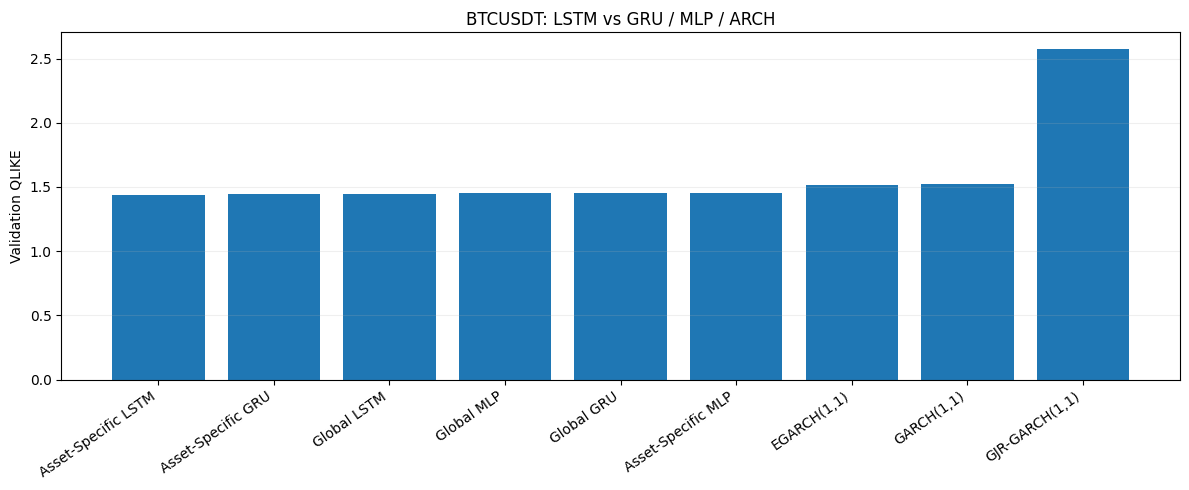

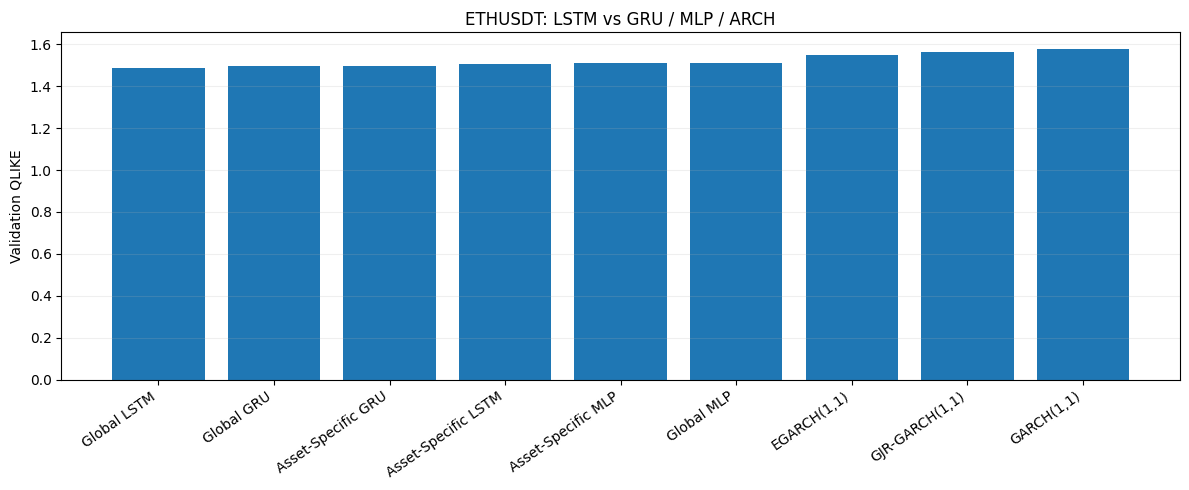

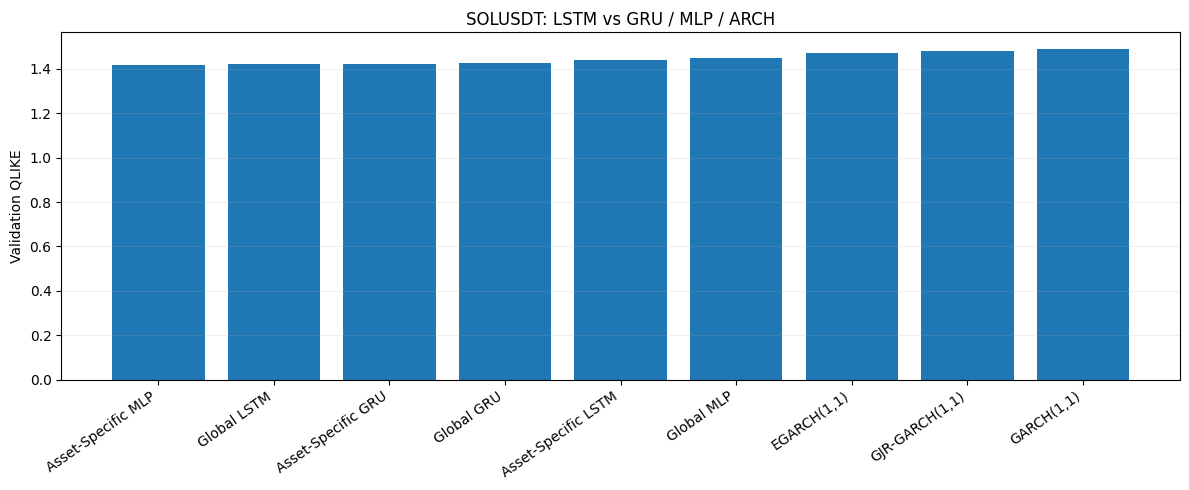

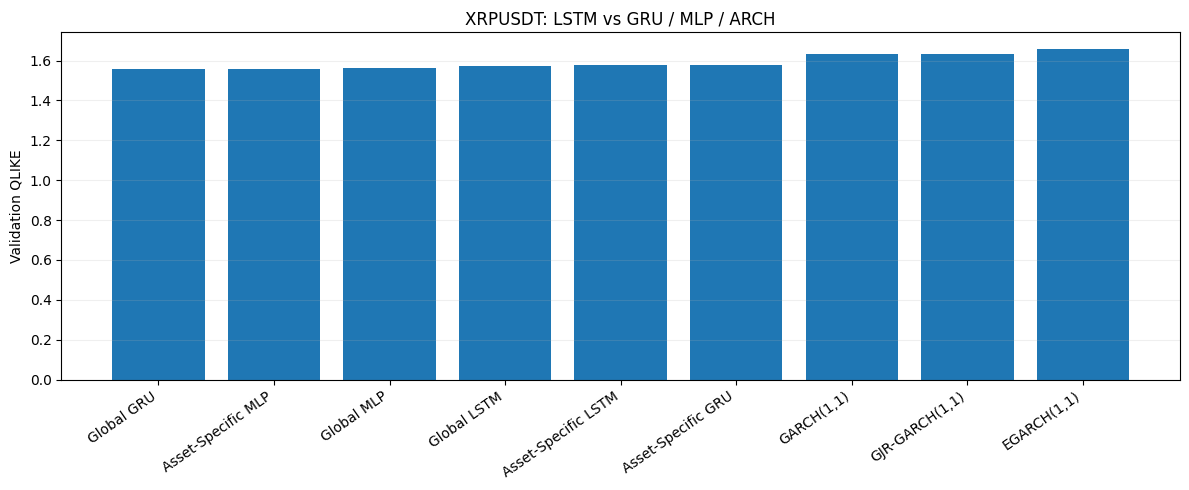

In [21]:
for symbol in SYMBOLS:
    x=fair_comparison_df.loc[fair_comparison_df["symbol"].eq(symbol)].sort_values("qlike")
    plt.figure(figsize=(12,5))
    plt.bar(x["model"],x["qlike"])
    plt.ylabel("Validation QLIKE")
    plt.title(f"{symbol}: LSTM vs GRU / MLP / ARCH")
    plt.xticks(rotation=35,ha="right")
    plt.grid(axis="y",alpha=0.2)
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT/f"{symbol}_lstm_gru_mlp_arch_qlike.png",dpi=200,bbox_inches="tight")
    plt.show()

## 20. Dynamic LSTM volatility plots

`ROLLING_VOLATILITY_WINDOW` remains dynamic. Change `"1d"` to `"12h"`, `"4h"`, etc. when needed.

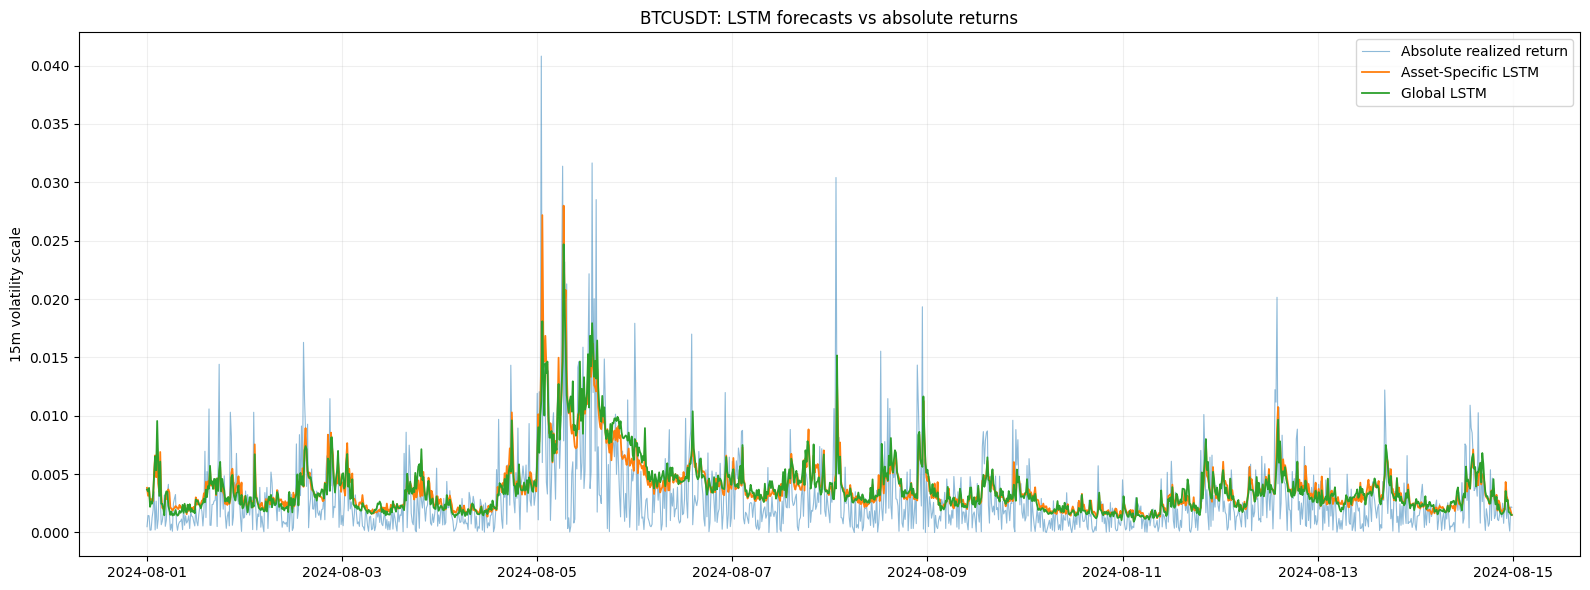

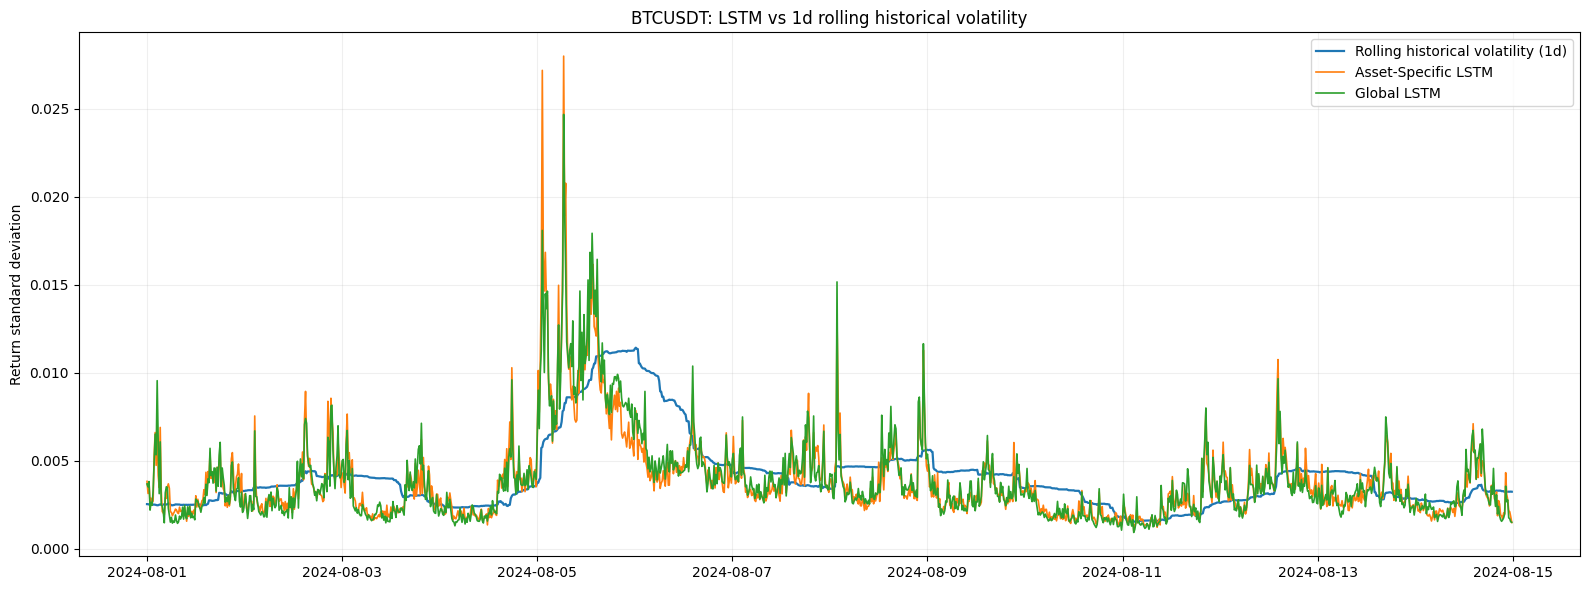

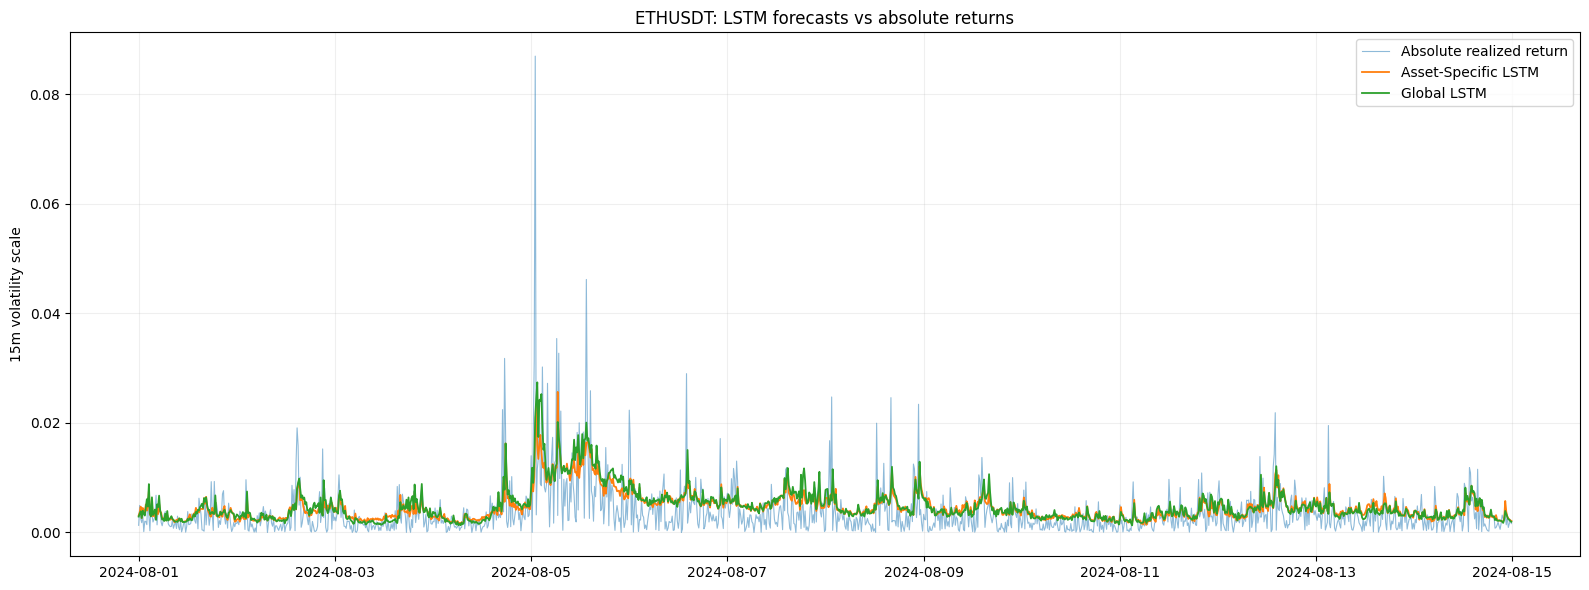

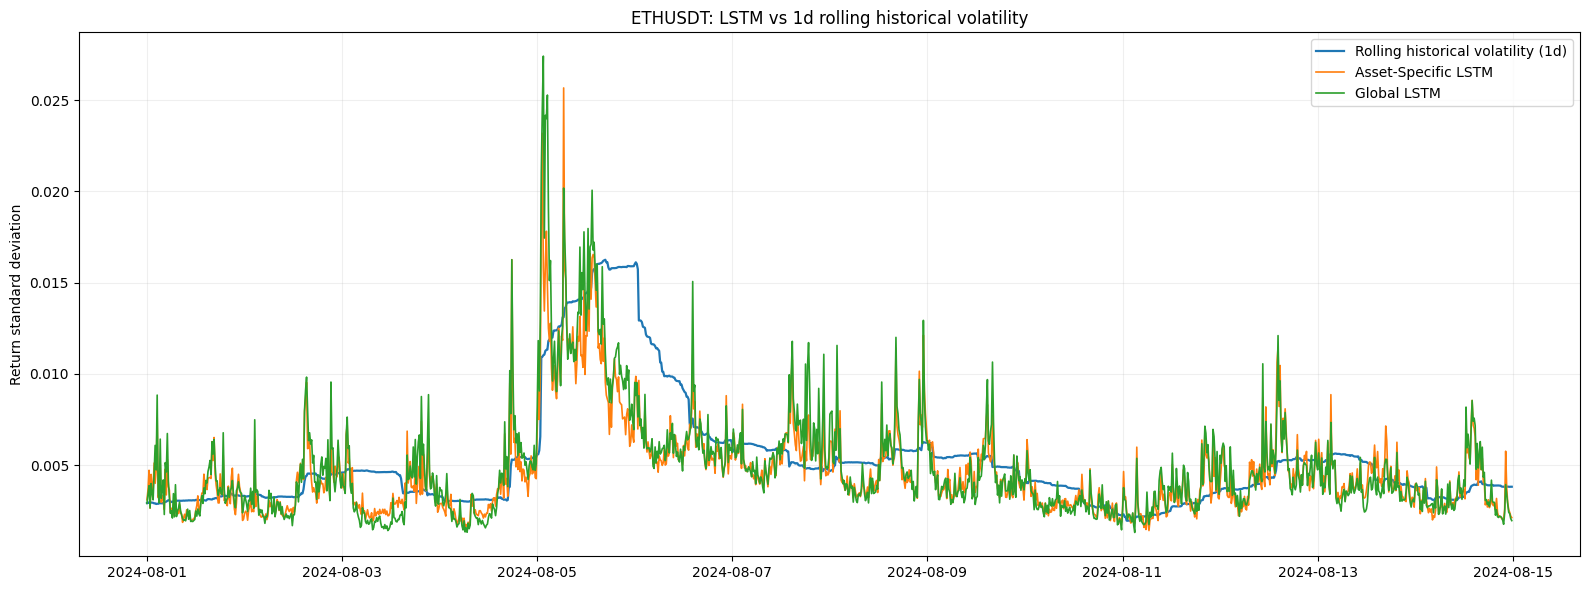

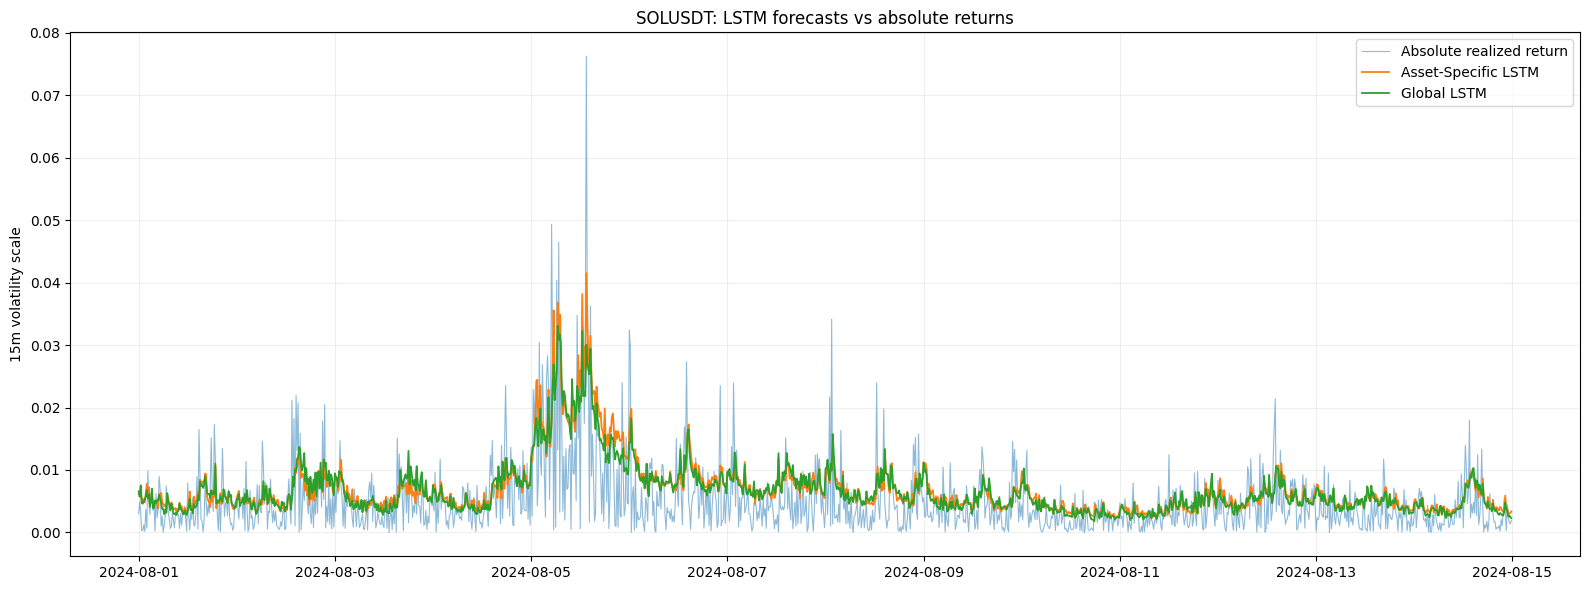

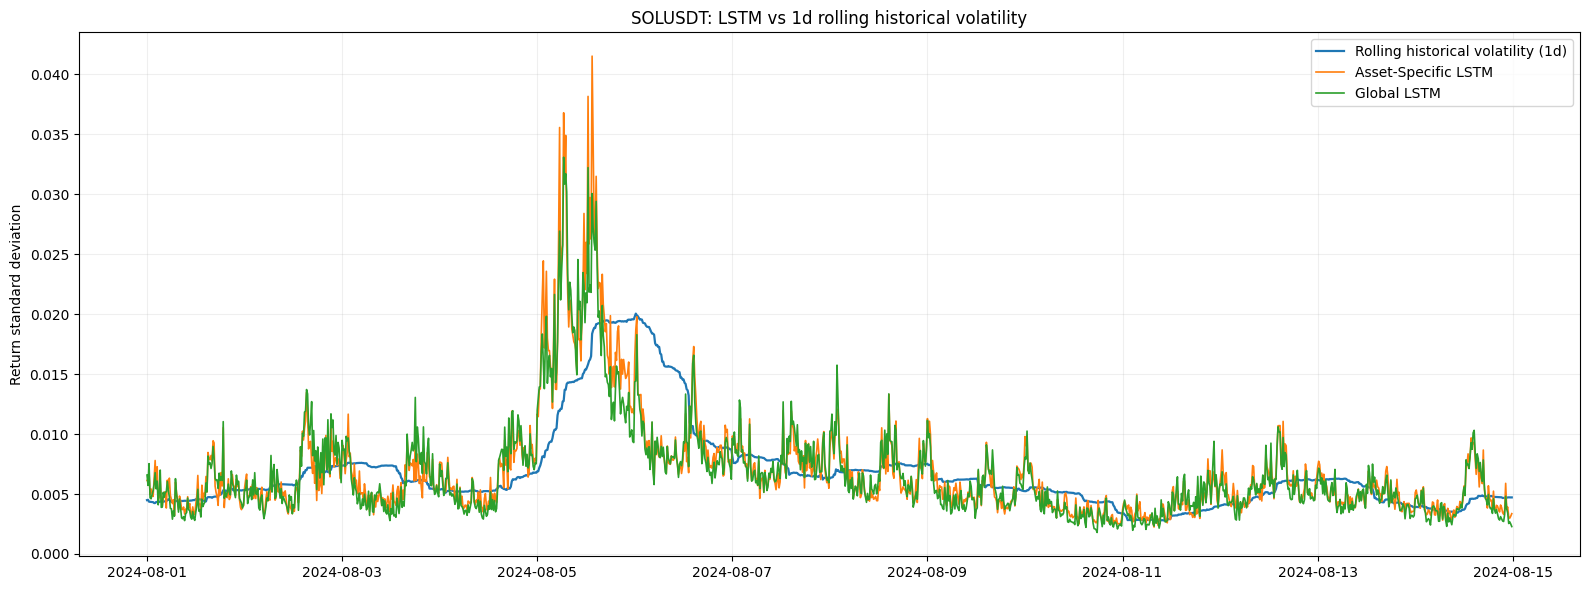

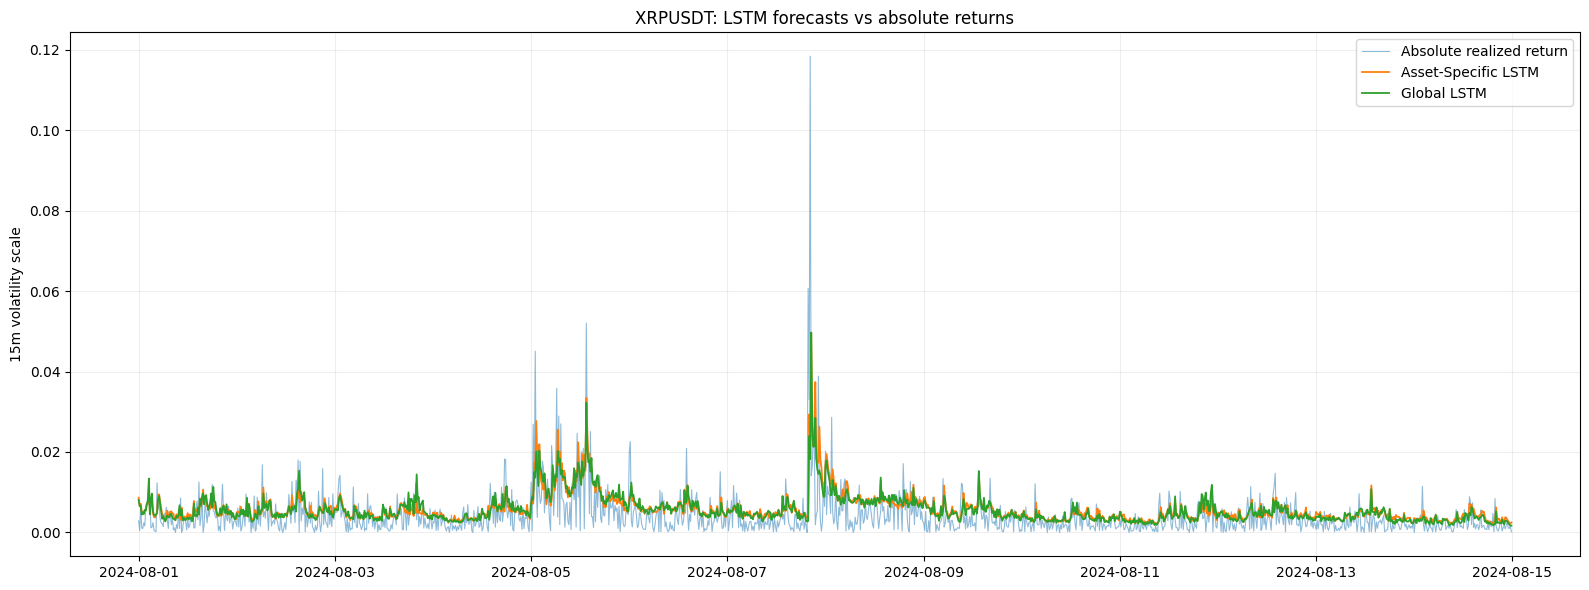

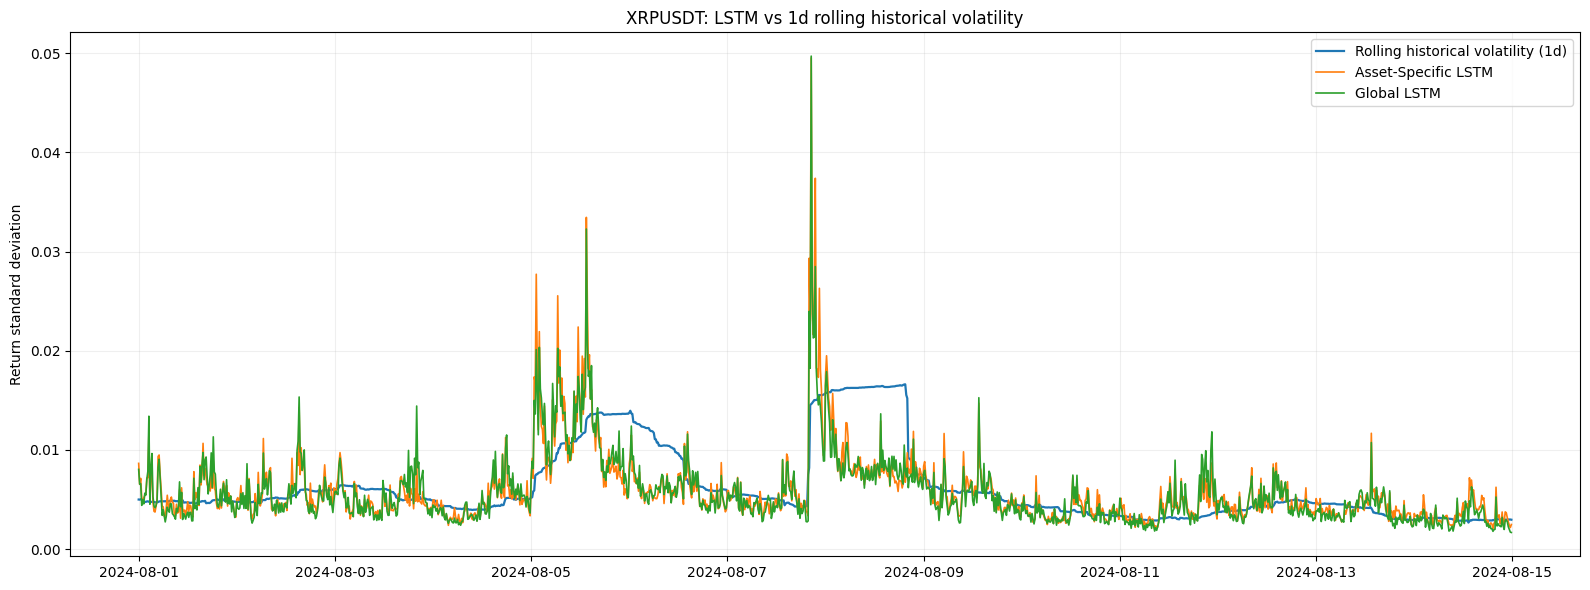

In [22]:
def strict_rolling_std(values,times,bars,ddof=1):
    std=values.rolling(bars,min_periods=bars).std(ddof=ddof)
    count=values.rolling(bars,min_periods=bars).count()
    start=times.shift(bars-1)
    exact=(times-start).eq((bars-1)*INTERVAL_DELTA)
    return std.where(count.eq(bars)&exact)

ROLLING_VOLATILITY_BARS=duration_to_bars_or_none(ROLLING_VOLATILITY_WINDOW)
if ROLLING_VOLATILITY_BARS is None or ROLLING_VOLATILITY_BARS<2:
    raise ValueError("Invalid rolling-volatility window.")

parts=[]
for symbol in SYMBOLS:
    x=features_df.loc[features_df["symbol"].eq(symbol)].sort_values("open_time").copy()
    x["absolute_return"]=x["return"].abs()
    x["rolling_historical_volatility"]=strict_rolling_std(
        x["return"],x["open_time"],ROLLING_VOLATILITY_BARS,1
    )
    parts.append(
        x[["symbol","open_time","absolute_return","rolling_historical_volatility"]]
        .rename(columns={"open_time":"target_open_time"})
    )
proxy_df=pd.concat(parts,ignore_index=True)

plot_df=(
    proxy_df
    .merge(
        asset_lstm_predictions_df[["symbol","target_open_time","predicted_variance"]]
        .rename(columns={"predicted_variance":"asset_lstm_variance"}),
        on=["symbol","target_open_time"],how="inner",validate="one_to_one"
    )
    .merge(
        global_lstm_predictions_df[["symbol","target_open_time","predicted_variance"]]
        .rename(columns={"predicted_variance":"global_lstm_variance"}),
        on=["symbol","target_open_time"],how="inner",validate="one_to_one"
    )
)

plot_df["asset_lstm_volatility"]=np.sqrt(plot_df["asset_lstm_variance"])
plot_df["global_lstm_volatility"]=np.sqrt(plot_df["global_lstm_variance"])

plot_start=VALIDATION_START if PLOT_START is None else pd.Timestamp(PLOT_START)
if plot_start.tzinfo is None:
    plot_start=plot_start.tz_localize("UTC")
else:
    plot_start=plot_start.tz_convert("UTC")
plot_end=plot_start+pd.Timedelta(PLOT_WINDOW_DURATION)

for symbol in SYMBOLS:
    x=plot_df.loc[
        plot_df["symbol"].eq(symbol)
        & plot_df["target_open_time"].ge(plot_start)
        & plot_df["target_open_time"].lt(plot_end)
    ].sort_values("target_open_time")

    plt.figure(figsize=(16,6))
    plt.plot(x["target_open_time"],x["absolute_return"],label="Absolute realized return",linewidth=0.8,alpha=0.5)
    plt.plot(x["target_open_time"],x["asset_lstm_volatility"],label="Asset-Specific LSTM",linewidth=1.3)
    plt.plot(x["target_open_time"],x["global_lstm_volatility"],label="Global LSTM",linewidth=1.3)
    plt.title(f"{symbol}: LSTM forecasts vs absolute returns")
    plt.ylabel(f"{KLINE_INTERVAL} volatility scale")
    plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
    plt.savefig(RESULTS_ROOT/f"{symbol}_lstm_vs_absolute_return.png",dpi=200,bbox_inches="tight")
    plt.show()

    y=x.loc[x["rolling_historical_volatility"].notna()]
    plt.figure(figsize=(16,6))
    plt.plot(y["target_open_time"],y["rolling_historical_volatility"],label=f"Rolling historical volatility ({ROLLING_VOLATILITY_WINDOW})",linewidth=1.6)
    plt.plot(y["target_open_time"],y["asset_lstm_volatility"],label="Asset-Specific LSTM",linewidth=1.2)
    plt.plot(y["target_open_time"],y["global_lstm_volatility"],label="Global LSTM",linewidth=1.2)
    plt.title(f"{symbol}: LSTM vs {ROLLING_VOLATILITY_WINDOW} rolling historical volatility")
    plt.ylabel("Return standard deviation")
    plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
    plt.savefig(RESULTS_ROOT/f"{symbol}_lstm_vs_rolling_{duration_tag(ROLLING_VOLATILITY_WINDOW)}.png",dpi=200,bbox_inches="tight")
    plt.show()

# Part E — Save the completed final LSTM outputs

In [23]:
# Aggregate LSTM outputs that the interrupted Notebook 06 never reached.

ASSET_METRICS_PATH = (
    RESULTS_ROOT
    / "asset_specific_lstm_validation_metrics.csv"
)

ASSET_PREDICTIONS_PATH = (
    RESULTS_ROOT
    / "asset_specific_lstm_validation_predictions.parquet"
)

GLOBAL_METRICS_PATH = (
    RESULTS_ROOT
    / "global_lstm_validation_metrics.csv"
)

GLOBAL_PREDICTIONS_PATH = (
    RESULTS_ROOT
    / "global_lstm_validation_predictions.parquet"
)

COMPARISON_PATH = (
    RESULTS_ROOT
    / "lstm_gru_mlp_arch_validation_comparison.csv"
)

COVERAGE_PATH = (
    RESULTS_ROOT
    / "fair_validation_date_coverage.csv"
)

PLOT_DATA_PATH = (
    RESULTS_ROOT
    / (
        "lstm_volatility_plot_data_"
        f"{duration_tag(ROLLING_VOLATILITY_WINDOW)}.parquet"
    )
)

GLOBAL_HISTORY_PATH = (
    RESULTS_ROOT
    / "global_lstm_final_train_history.csv"
)

CONFIG_PATH = (
    RESULTS_ROOT
    / "final_lstm_configuration.json"
)


asset_lstm_metrics_df.to_csv(
    ASSET_METRICS_PATH,
    index=False,
)

asset_lstm_predictions_df.to_parquet(
    ASSET_PREDICTIONS_PATH,
    index=False,
)

global_lstm_metrics_df.to_csv(
    GLOBAL_METRICS_PATH,
    index=False,
)

global_lstm_predictions_df.to_parquet(
    GLOBAL_PREDICTIONS_PATH,
    index=False,
)

fair_comparison_df.to_csv(
    COMPARISON_PATH,
    index=False,
)

comparison_dates_df.to_csv(
    COVERAGE_PATH,
    index=False,
)

plot_df.to_parquet(
    PLOT_DATA_PATH,
    index=False,
)


global_history_df = pd.DataFrame(
    global_history.history
)

global_history_df[
    "epoch"
] = np.arange(
    1,
    len(
        global_history_df
    )
    + 1,
)

global_history_df.to_csv(
    GLOBAL_HISTORY_PATH,
    index=False,
)


configuration = {
    "created_at_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "model_family":
        "Final Enhanced LSTM",

    "recovery_notebook":
        True,

    "recovery_reason":
        "Original runtime disconnected during final global LSTM training",

    "kline_interval":
        KLINE_INTERVAL,

    "interval_minutes":
        INTERVAL_MINUTES,

    "forecast_horizon":
        "one_candle_ahead",

    "target":
        "next_candle_squared_log_return",

    "training_target":
        "deseasonalized_next_candle_variance",

    "loss":
        "gaussian_variance_quasi_likelihood_qlike_aligned",

    "selected_sequence_duration":
        SELECTED_LSTM_DURATION,

    "selected_sequence_bars":
        SELECTED_LSTM_BARS,

    "selected_learning_rate":
        SELECTED_LSTM_LR,

    "selected_epoch_by_asset":
        SELECTED_EPOCH_BY_ASSET,

    "global_selected_epochs":
        GLOBAL_FINAL_EPOCHS,

    "global_epoch_source":
        "completed inner-global tuning in interrupted Notebook 06",

    "state_features":
        STATE_FEATURE_COLUMNS,

    "sequence_features":
        SEQUENCE_FEATURE_COLUMNS,

    "lstm_units":
        LSTM_UNITS,

    "temporal_attention":
        True,

    "global_asset_balanced_weights":
        True,

    "rolling_volatility_window":
        ROLLING_VOLATILITY_WINDOW,

    "hyperparameters_retuned_in_recovery":
        False,

    "test_evaluated":
        False,
}


CONFIG_PATH.write_text(
    json.dumps(
        configuration,
        indent=2,
    ),
    encoding="utf-8",
)


print(
    "FINAL LSTM RECOVERY OUTPUTS SAVED."
)

for path in [
    ASSET_METRICS_PATH,
    ASSET_PREDICTIONS_PATH,
    GLOBAL_METRICS_PATH,
    GLOBAL_PREDICTIONS_PATH,
    COMPARISON_PATH,
    COVERAGE_PATH,
    PLOT_DATA_PATH,
    GLOBAL_HISTORY_PATH,
    CONFIG_PATH,
    GLOBAL_MODEL_PATH,
    GLOBAL_SCALERS_PATH,
]:
    print(
        " -",
        path,
    )

FINAL LSTM RECOVERY OUTPUTS SAVED.
 - /content/drive/MyDrive/Quant Research/15min/results/15m/LSTM_FINAL/asset_specific_lstm_validation_metrics.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/LSTM_FINAL/asset_specific_lstm_validation_predictions.parquet
 - /content/drive/MyDrive/Quant Research/15min/results/15m/LSTM_FINAL/global_lstm_validation_metrics.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/LSTM_FINAL/global_lstm_validation_predictions.parquet
 - /content/drive/MyDrive/Quant Research/15min/results/15m/LSTM_FINAL/lstm_gru_mlp_arch_validation_comparison.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/LSTM_FINAL/fair_validation_date_coverage.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/LSTM_FINAL/lstm_volatility_plot_data_1d.parquet
 - /content/drive/MyDrive/Quant Research/15min/results/15m/LSTM_FINAL/global_lstm_final_train_history.csv
 - /content/drive/MyDrive/Quant Research/15min/results/15m/LSTM_FINAL/final_lstm_c

## 21. Final recovery QC

In [24]:
# ------------------------------------------------------------
# Test remains sealed.
# ------------------------------------------------------------

for prediction_df in [
    asset_lstm_predictions_df,
    global_lstm_predictions_df,
]:

    prediction_df[
        "target_open_time"
    ] = pd.to_datetime(
        prediction_df[
            "target_open_time"
        ],
        utc=True,
        errors="raise",
    )

    assert (
        prediction_df[
            "target_open_time"
        ]
        .ge(
            VALIDATION_START
        )
        .all()
    )

    assert (
        prediction_df[
            "target_open_time"
        ]
        .lt(
            TEST_START
        )
        .all()
    )

    assert not prediction_df.duplicated(
        [
            "symbol",
            "target_open_time",
        ]
    ).any()

    assert np.isfinite(
        prediction_df[
            "predicted_variance"
        ]
        .to_numpy(
            dtype=float
        )
    ).all()

    assert (
        prediction_df[
            "predicted_variance"
        ]
        .gt(0)
        .all()
    )


# ------------------------------------------------------------
# Full Validation coverage.
# ------------------------------------------------------------

for symbol in SYMBOLS:

    asset_count = (
        asset_lstm_predictions_df[
            "symbol"
        ]
        .eq(
            symbol
        )
        .sum()
    )

    global_count = (
        global_lstm_predictions_df[
            "symbol"
        ]
        .eq(
            symbol
        )
        .sum()
    )

    assert (
        asset_count
        == EXPECTED_VALIDATION_ROWS
    )

    assert (
        global_count
        == EXPECTED_VALIDATION_ROWS
    )


# ------------------------------------------------------------
# All expected final models in comparison.
# ------------------------------------------------------------

expected_models = {
    "Asset-Specific LSTM",
    "Global LSTM",
    "Asset-Specific GRU",
    "Global GRU",
    "Asset-Specific MLP",
    "Global MLP",
    "GARCH(1,1)",
    "GJR-GARCH(1,1)",
    "EGARCH(1,1)",
}

for symbol in SYMBOLS:

    current = (
        fair_comparison_df.loc[
            fair_comparison_df[
                "symbol"
            ].eq(
                symbol
            )
        ]
    )

    assert (
        set(
            current[
                "model"
            ]
        )
        == expected_models
    )


# ------------------------------------------------------------
# Saved artifacts.
# ------------------------------------------------------------

assert GLOBAL_MODEL_PATH.exists()
assert GLOBAL_SCALERS_PATH.exists()

for symbol in SYMBOLS:

    assert (
        ASSET_MODEL_PATHS[
            symbol
        ]
        .exists()
    )

    assert (
        ASSET_SCALER_PATHS[
            symbol
        ]
        .exists()
    )


for metric_df in [
    asset_lstm_metrics_df,
    global_lstm_metrics_df,
]:

    assert np.isfinite(
        metric_df[
            [
                "mae",
                "rmse",
                "qlike",
            ]
        ]
        .to_numpy(
            dtype=float
        )
    ).all()

    assert (
        metric_df[
            "qlike"
        ]
        .ge(
            -1e-12
        )
        .all()
    )


print(
    "ALL LSTM RECOVERY QC CHECKS PASSED."
)

print(
    "Frozen LSTM lookback:",
    SELECTED_LSTM_DURATION,
    "=",
    SELECTED_LSTM_BARS,
    "bars",
)

print(
    "Frozen LR:",
    SELECTED_LSTM_LR,
)

print(
    "Frozen global epochs:",
    GLOBAL_FINAL_EPOCHS,
)

print(
    "\nFinal Validation ranking:"
)

display(
    fair_comparison_df
    .sort_values(
        [
            "symbol",
            "qlike",
        ]
    )
)

print(
    "\nTest remains untouched."
)

ALL LSTM RECOVERY QC CHECKS PASSED.
Frozen LSTM lookback: 12h = 48 bars
Frozen LR: 0.0003
Frozen global epochs: 21

Final Validation ranking:


,symbol,model,model_family,observations,mae,rmse,qlike,qlike_rank
0,BTCUSDT,Asset-Specific LSTM,Deep Learning,35040,0.000008,0.000030,1.436966,1
1,BTCUSDT,Asset-Specific GRU,Deep Learning,35040,0.000008,0.000030,1.446041,2
2,BTCUSDT,Global LSTM,Deep Learning,35040,0.000008,0.000030,1.447217,3
3,BTCUSDT,Global MLP,Deep Learning,35040,0.000008,0.000031,1.449854,4
4,BTCUSDT,Global GRU,Deep Learning,35040,0.000008,0.000031,1.450973,5
5,BTCUSDT,Asset-Specific MLP,Deep Learning,35040,0.000007,0.000030,1.451999,6
6,BTCUSDT,"EGARCH(1,1)",ARCH,35040,0.000008,0.000030,1.515321,7
7,BTCUSDT,"GARCH(1,1)",ARCH,35040,0.000008,0.000030,1.526979,8
8,BTCUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.000028,0.000039,2.575465,9
9,ETHUSDT,Global LSTM,Deep Learning,35040,0.000017,0.000095,1.488880,1



Test remains untouched.


# Recovery interpretation

This notebook does not create a new LSTM specification.

It completes the already-selected LSTM experiment after an infrastructure interruption.

Therefore:

- the 12h lookback is unchanged;
- the 3e-4 learning rate is unchanged;
- the 21 global epochs are unchanged;
- the four saved asset-specific models are reused rather than retrained;
- only the missing final pooled Global LSTM is trained;
- official Validation comparison is then completed;
- Test remains sealed.

This preserves the methodology of Notebook 06 while avoiding the ~10+ hours of repeated tuning and asset-specific training.